# WT vs MUT Butterfly Wing Comparative Study

This notebook implements a unified comparison pipeline for the two butterfly wing datasets.

It covers:
- shared preprocessing for WT and MUT
- full-wing clustering and semantic area comparison
- average spectra and difference spectra
- matched MLP training and validation comparison
- WT-to-MUT and MUT-to-WT cross-domain evaluation

In [16]:
import os
import random
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
from skimage.morphology import remove_small_objects, erosion, disk
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import umap.umap_ as umap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CLASS_NAMES = {
    0: "Lower Lamina",
    1: "Cross Ribs & Ridges",
    2: "Trabeculae",
}

DATASETS = {
    "WT": {
        "path": "./bicyclus_wt_c.h5",
        "roi": (0, 170, 150, 250),
        "test_roi": (0, 170, 250, 350), 
        "bg_threshold": 0.85,
        "bg_min_size": 2000,
        "merge": {
            "Trabeculae": [20, 54, 55, 56],
            "Cross Ribs&Ridges": [12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 48, 49, 50, 51, 52, 53, 57, 58],
            "Lower Lamina": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 59],
        },
    },
    "MUT": {
        "path": "./bicyclus_mut_c.h5",
        "roi": (150, 350, 80, 210),
        "test_roi": (150, 350, 211, 350), 
        "bg_threshold": 1.60,
        "bg_min_size": 1000,
        "merge": {
            "Trabeculae": [55, 56, 57, 58],
            "Cross Ribs&Ridges": [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 50, 51, 53, 54, 59],
            "Lower Lamina": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 43, 44, 45, 46, 47, 48, 49, 52],
        },
    },
}

COMMON_CFG = {
    "chosen_energy": 290.0,
    "preedge_cutoff": 285.0,
    "energy_grid": np.arange(280.0, 310.0, 1.0),
    "cluster_k": 60,
    "cluster_neighbors": 30,
    "cluster_min_dist": 0.10,
    "cluster_area_weight": 0.50,
    "test_size": 0.20,
    "batch_size": 2048,
    "max_epochs": 220,
    "lr": 5e-4,
    "weight_decay": 1e-4,
    "patience": 30,
    "hidden_dim": 512,
    "num_blocks": 6,
    "dropout": 0.10,
}

print("Common energy grid:", COMMON_CFG["energy_grid"][0], "to", COMMON_CFG["energy_grid"][-1], "eV")

Using device: cuda
Common energy grid: 280.0 to 309.0 eV


In [17]:
def circular_mean(theta, axis=0):
    return np.angle(np.mean(np.exp(1j * theta), axis=axis))


def robust_range(x, low=2, high=98):
    vals = x[np.isfinite(x)]
    if vals.size == 0:
        return 0.0, 1.0
    lo = np.nanpercentile(vals, low)
    hi = np.nanpercentile(vals, high)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.nanmin(vals))
        hi = float(np.nanmax(vals))
    return lo, hi


def smooth_nan_map(arr, sigma=1.2):
    mask = np.isfinite(arr).astype(np.float32)
    arr0 = np.nan_to_num(arr, nan=0.0).astype(np.float32)
    num = gaussian_filter(arr0 * mask, sigma=sigma)
    den = gaussian_filter(mask, sigma=sigma)
    out = num / np.maximum(den, 1e-8)
    out[den < 1e-6] = np.nan
    return out


def interp_cube_linear(cube, energy_src, energy_dst):
    e_in, h, w = cube.shape
    flat = cube.reshape(e_in, -1)
    interp_fn = interp1d(energy_src, flat, axis=0, kind="linear", bounds_error=False, fill_value="extrapolate")
    out = interp_fn(energy_dst).astype(np.float32)
    return out.reshape(len(energy_dst), h, w)


def interp_phase_cube(phase_cube, energy_src, energy_dst):
    sin_cube = np.sin(phase_cube)
    cos_cube = np.cos(phase_cube)
    sin_i = interp_cube_linear(sin_cube, energy_src, energy_dst)
    cos_i = interp_cube_linear(cos_cube, energy_src, energy_dst)
    return np.angle(cos_i + 1j * sin_i)


def load_and_preprocess(name, cfg, common_cfg):
    path = cfg["path"]
    assert os.path.exists(path), f"Missing file: {path}"

    with h5py.File(path, "r") as f:
        amplitude_im = np.asarray(f["amplitude"], dtype=np.float32)
        phase_im = np.asarray(f["phase"], dtype=np.float32)
        energy = np.asarray(f["energy_ev"], dtype=np.float32)

    energy_idx = int(np.argmin(np.abs(energy - common_cfg["chosen_energy"])))
    img = amplitude_im[energy_idx]

    bg_mask = img >= cfg["bg_threshold"]
    bg_mask = remove_small_objects(bg_mask, min_size=cfg["bg_min_size"])
    bg_mask = erosion(bg_mask, disk(1))

    bg_mean = amplitude_im[:, bg_mask].mean(axis=1)
    bg_phase = phase_im[:, bg_mask]
    phase_bg_mean = np.angle(np.mean(np.exp(1j * bg_phase), axis=1))

    eps = 1e-1
    bg_mean_reshape = bg_mean.reshape(-1, 1, 1)
    absorption = -2.0 * np.log((np.abs(amplitude_im) + eps) / (np.abs(bg_mean_reshape) + eps))
    phase_corrected = np.angle(np.exp(1j * (phase_im - phase_bg_mean[:, None, None])))

    absorption_masked = absorption.copy()
    absorption_masked[:, bg_mask] = np.nan
    phase_masked = phase_corrected.copy()
    phase_masked[:, bg_mask] = np.nan

    data_cube = absorption_masked.copy()
    mask_pre = energy < common_cfg["preedge_cutoff"]
    e_pre = energy[mask_pre]
    e0 = float(e_pre.min())
    d_e = e_pre - e0

    pre_flat = data_cube[mask_pre].reshape(len(e_pre), -1)
    valid_cols = np.all(np.isfinite(pre_flat), axis=0) & np.all(pre_flat > 0, axis=0)

    A_fit = np.full(pre_flat.shape[1], np.nan, dtype=np.float32)
    B_fit = np.full(pre_flat.shape[1], np.nan, dtype=np.float32)
    if np.any(valid_cols):
        y = np.log(np.maximum(pre_flat[:, valid_cols], 1e-8))
        x = d_e[:, None]
        x_mean = x.mean(axis=0)
        y_mean = y.mean(axis=0)
        cov = ((x - x_mean) * (y - y_mean)).sum(axis=0)
        var = ((x - x_mean) ** 2).sum(axis=0)
        slope = cov / np.maximum(var, 1e-8)
        intercept = y_mean - slope * x_mean
        A_fit[valid_cols] = np.exp(intercept).astype(np.float32)
        B_fit[valid_cols] = (-slope).astype(np.float32)

    h, w = bg_mask.shape
    A_fit = A_fit.reshape(h, w)
    B_fit = B_fit.reshape(h, w)
    d_e_full = (energy - e0)[:, None, None]
    preedge_baseline = A_fit[None, :, :] * np.exp(-B_fit[None, :, :] * d_e_full)
    preedge_removed = data_cube - preedge_baseline
    np.maximum(preedge_removed, 0.0, out=preedge_removed)
    preedge_removed_masked = preedge_removed.copy()
    preedge_removed_masked[:, bg_mask] = np.nan

    x1, x2, y1, y2 = cfg["roi"]
    roi_mask = np.zeros_like(bg_mask, dtype=bool)
    roi_mask[y1:y2, x1:x2] = True
    foreground_mask = ~bg_mask
    test_roi = cfg.get("test_roi", None)
    if test_roi is not None:
        tx1, tx2, ty1, ty2 = test_roi
        test_mask = foreground_mask.copy()
        test_mask[:, :] = False
        test_mask[ty1:ty2, tx1:tx2] = True
        test_mask = test_mask & foreground_mask
    else:
        test_mask = foreground_mask.copy()
        test_mask[y1:y2, x1:x2] = False

    abs_interp = interp_cube_linear(absorption_masked, energy, common_cfg["energy_grid"])
    phase_interp = interp_phase_cube(phase_masked, energy, common_cfg["energy_grid"])

    return {
        "name": name,
        "path": path,
        "energy": energy,
        "energy_interp": common_cfg["energy_grid"],
        "amplitude_im": amplitude_im,
        "phase_im": phase_im,
        "bg_mask": bg_mask,
        "foreground_mask": foreground_mask,
        "roi": (x1, x2, y1, y2),
        "roi_mask": roi_mask,
        "test_mask": test_mask,
        "absorption_masked": absorption_masked,
        "phase_masked": phase_masked,
        "preedge_removed_masked": preedge_removed_masked,
        "avg_absorbance": np.nanmean(absorption_masked, axis=0),
        "avg_preedge_removed": np.nanmean(preedge_removed_masked, axis=0),
        "abs_interp": abs_interp,
        "phase_interp": phase_interp,
    }


def cluster_full_wing(data, cfg, common_cfg):
    cube = data["preedge_removed_masked"]
    e_len, h, w = cube.shape
    x = cube.transpose(1, 2, 0).reshape(-1, e_len)
    valid = (~data["bg_mask"].reshape(-1)) & (~np.isnan(x).any(axis=1))
    xv = x[valid]

    area = xv.sum(axis=1, keepdims=True)
    xfeat = np.hstack([xv, common_cfg["cluster_area_weight"] * area])
    scaler = StandardScaler()
    xv_s = scaler.fit_transform(xfeat)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=common_cfg["cluster_neighbors"],
        min_dist=common_cfg["cluster_min_dist"],
        metric="euclidean",
        random_state=SEED,
    )
    emb = reducer.fit_transform(xv_s)

    kmeans = KMeans(n_clusters=common_cfg["cluster_k"], random_state=SEED, n_init="auto")
    labels_v = kmeans.fit_predict(emb)
    centers = kmeans.cluster_centers_

    start = np.argmin(centers[:, 0])
    unused = set(range(common_cfg["cluster_k"]))
    unused.remove(start)
    order = [start]
    while unused:
        last = order[-1]
        rest = np.array(list(unused))
        dists = np.linalg.norm(centers[rest] - centers[last], axis=1)
        nxt = rest[np.argmin(dists)]
        order.append(nxt)
        unused.remove(nxt)

    old_to_new = np.empty(common_cfg["cluster_k"], dtype=int)
    for new_id, old_id in enumerate(order):
        old_to_new[old_id] = new_id

    labels_v = old_to_new[labels_v]
    centers = centers[order]

    labels_flat = np.full(h * w, -1, dtype=np.int32)
    labels_flat[valid] = labels_v
    labels_full = labels_flat.reshape(h, w)

    semantic_full = np.full_like(labels_full, fill_value=-1, dtype=np.int32)
    semantic_full[np.isin(labels_full, cfg["merge"]["Lower Lamina"])] = 0
    semantic_full[np.isin(labels_full, cfg["merge"]["Cross Ribs&Ridges"])] = 1
    semantic_full[np.isin(labels_full, cfg["merge"]["Trabeculae"])] = 2

    data["task5_scaler"] = scaler
    data["umap_embedding"] = emb
    data["cluster_centers"] = centers
    data["cluster_valid_mask"] = valid.reshape(h, w)
    data["cluster_labels_full"] = labels_full
    data["semantic_full"] = semantic_full
    data["semantic_roi"] = semantic_full[data["roi"][2]:data["roi"][3], data["roi"][0]:data["roi"][1]].copy()
    return data


def mean_std_spectrum(cube, mask, energy_grid=None):
    if energy_grid is not None and cube.shape[0] != len(energy_grid):
        raise ValueError("cube first dimension does not match energy grid")
    pixels = cube[:, mask]
    return np.nanmean(pixels, axis=1), np.nanstd(pixels, axis=1)


def semantic_fraction_table(data_dict):
    rows = []
    for name, data in data_dict.items():
        fg = data["foreground_mask"]
        denom = max(int(fg.sum()), 1)
        for class_id, class_name in CLASS_NAMES.items():
            count = int(np.sum(data["semantic_full"] == class_id))
            rows.append({
                "dataset": name,
                "class_id": class_id,
                "class_name": class_name,
                "pixels": count,
                "fraction": count / denom,
            })
    return pd.DataFrame(rows)


def build_roi_semantic_mask(data, class_id):
    x1, x2, y1, y2 = data["roi"]
    out = np.zeros_like(data["foreground_mask"], dtype=bool)
    out[y1:y2, x1:x2] = data["semantic_roi"] == class_id
    return out

In [18]:
datasets = {}
for name, cfg in DATASETS.items():
    print(f"Loading and preprocessing {name} ...")
    data = load_and_preprocess(name, cfg, COMMON_CFG)
    print(f"Clustering full wing for {name} ...")
    data = cluster_full_wing(data, cfg, COMMON_CFG)
    datasets[name] = data

for name, data in datasets.items():
    x1, x2, y1, y2 = data["roi"]
    print(
        f"{name}: energy={len(data['energy'])}, foreground={int(data['foreground_mask'].sum())}, "
        f"ROI=({x1},{x2},{y1},{y2}), test_pixels={int(data['test_mask'].sum())}"
    )

Loading and preprocessing WT ...
Clustering full wing for WT ...
Loading and preprocessing MUT ...
Clustering full wing for MUT ...
WT: energy=76, foreground=83637, ROI=(0,170,150,250), test_pixels=17000
MUT: energy=77, foreground=115317, ROI=(150,350,80,210), test_pixels=27800


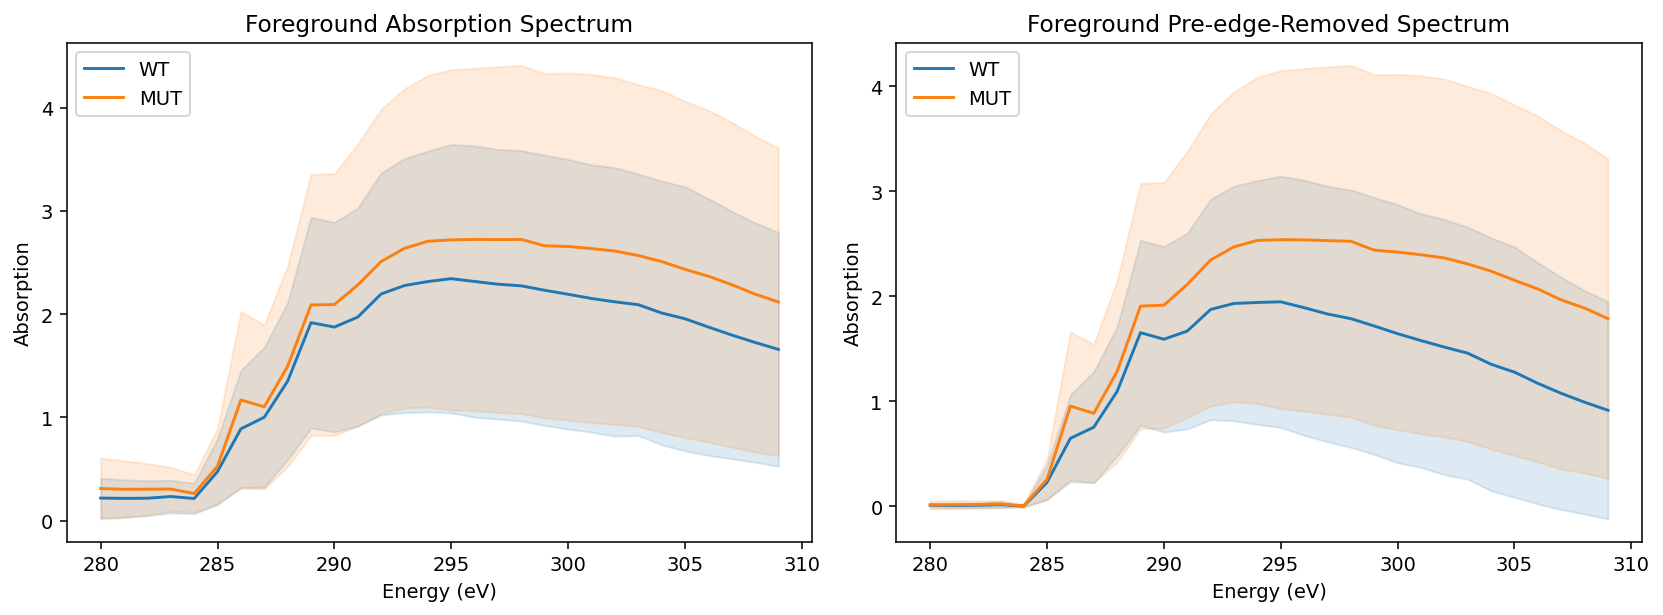

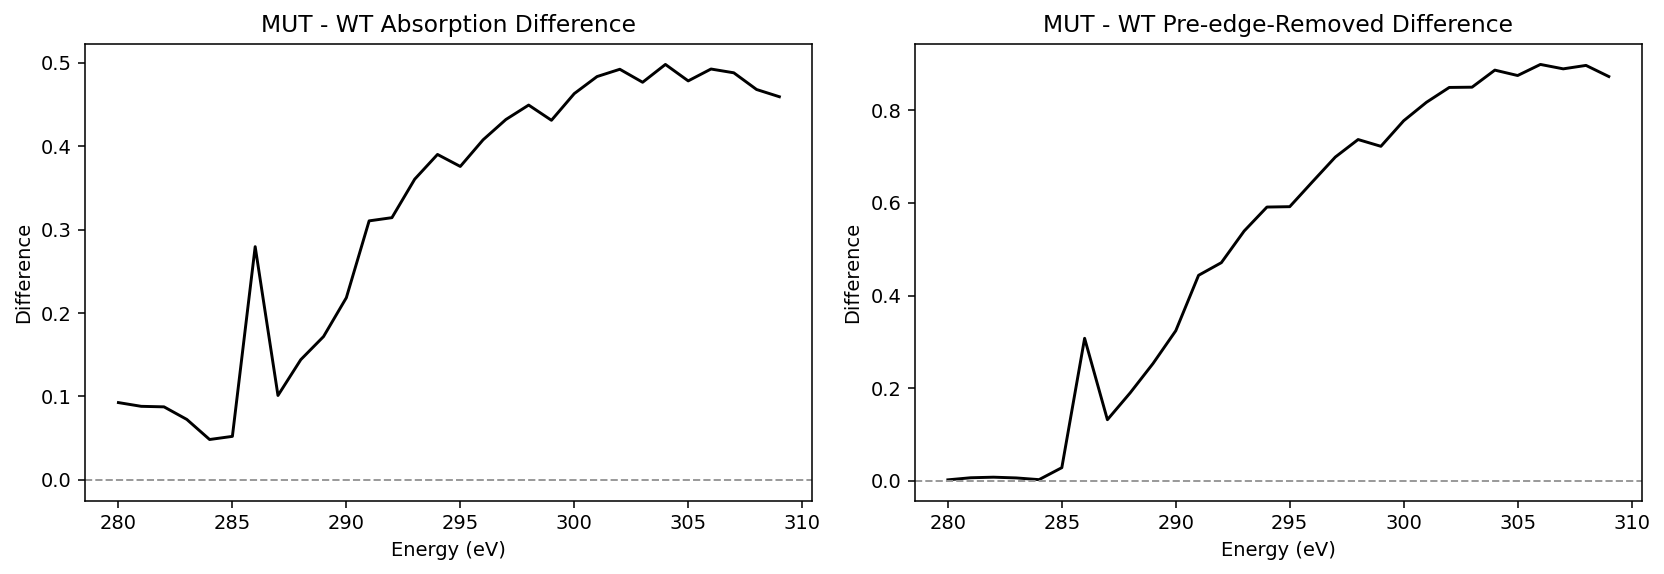

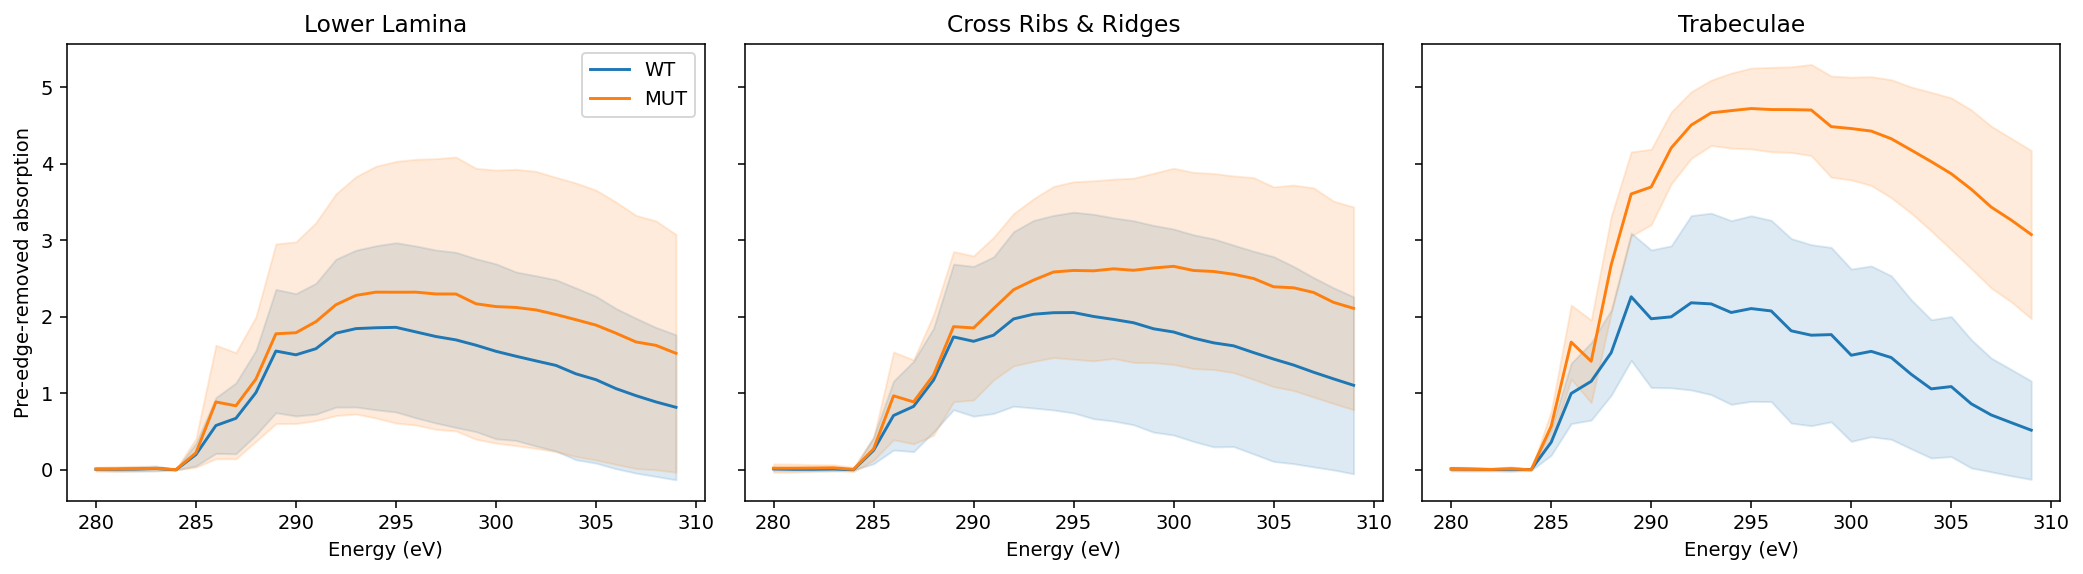

,dataset,abs_peak,abs_area,pre_peak,pre_area
0,WT,2.343087,47.443164,1.945809,35.085597
1,MUT,2.723573,56.795425,2.537511,49.959420


In [19]:
# Spectra comparison: overall foreground and per semantic class on the common energy grid
energy_grid = COMMON_CFG["energy_grid"]
pre_interp = {
    name: interp_cube_linear(data["preedge_removed_masked"], data["energy"], energy_grid)
    for name, data in datasets.items()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=140)
for name, color in [("WT", "tab:blue"), ("MUT", "tab:orange")]:
    data = datasets[name]
    mean_abs, std_abs = mean_std_spectrum(data["abs_interp"], data["foreground_mask"], energy_grid)
    mean_pre, std_pre = mean_std_spectrum(pre_interp[name], data["foreground_mask"], energy_grid)

    axes[0].plot(energy_grid, mean_abs, label=name, color=color)
    axes[0].fill_between(energy_grid, mean_abs - std_abs, mean_abs + std_abs, color=color, alpha=0.15)
    axes[1].plot(energy_grid, mean_pre, label=name, color=color)
    axes[1].fill_between(energy_grid, mean_pre - std_pre, mean_pre + std_pre, color=color, alpha=0.15)

axes[0].set_title("Foreground Absorption Spectrum")
axes[0].set_xlabel("Energy (eV)")
axes[0].set_ylabel("Absorption")
axes[0].legend()

axes[1].set_title("Foreground Pre-edge-Removed Spectrum")
axes[1].set_xlabel("Energy (eV)")
axes[1].set_ylabel("Absorption")
axes[1].legend()
plt.tight_layout()
plt.show()

wt_abs_mean, _ = mean_std_spectrum(datasets["WT"]["abs_interp"], datasets["WT"]["foreground_mask"], energy_grid)
mut_abs_mean, _ = mean_std_spectrum(datasets["MUT"]["abs_interp"], datasets["MUT"]["foreground_mask"], energy_grid)
wt_pre_mean, _ = mean_std_spectrum(pre_interp["WT"], datasets["WT"]["foreground_mask"], energy_grid)
mut_pre_mean, _ = mean_std_spectrum(pre_interp["MUT"], datasets["MUT"]["foreground_mask"], energy_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=140)
axes[0].plot(energy_grid, mut_abs_mean - wt_abs_mean, color="black")
axes[0].axhline(0.0, color="0.6", ls="--", lw=1)
axes[0].set_title("MUT - WT Absorption Difference")
axes[0].set_xlabel("Energy (eV)")
axes[0].set_ylabel("Difference")

axes[1].plot(energy_grid, mut_pre_mean - wt_pre_mean, color="black")
axes[1].axhline(0.0, color="0.6", ls="--", lw=1)
axes[1].set_title("MUT - WT Pre-edge-Removed Difference")
axes[1].set_xlabel("Energy (eV)")
axes[1].set_ylabel("Difference")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=140, sharey=True)
for ax, class_id in zip(axes, [0, 1, 2]):
    class_name = CLASS_NAMES[class_id]
    for name, color in [("WT", "tab:blue"), ("MUT", "tab:orange")]:
        data = datasets[name]
        mask = data["semantic_full"] == class_id
        mean_c, std_c = mean_std_spectrum(pre_interp[name], mask, energy_grid)
        ax.plot(energy_grid, mean_c, color=color, label=name)
        ax.fill_between(energy_grid, mean_c - std_c, mean_c + std_c, color=color, alpha=0.15)
    ax.set_title(class_name)
    ax.set_xlabel("Energy (eV)")
axes[0].set_ylabel("Pre-edge-removed absorption")
axes[0].legend()
plt.tight_layout()
plt.show()

summary_rows = []
for name, data in datasets.items():
    mean_abs, _ = mean_std_spectrum(data["abs_interp"], data["foreground_mask"], energy_grid)
    mean_pre, _ = mean_std_spectrum(pre_interp[name], data["foreground_mask"], energy_grid)
    summary_rows.append({
        "dataset": name,
        "abs_peak": float(np.nanmax(mean_abs)),
        "abs_area": float(np.trapz(mean_abs, energy_grid)),
        "pre_peak": float(np.nanmax(mean_pre)),
        "pre_area": float(np.trapz(mean_pre, energy_grid)),
    })

spectra_summary_df = pd.DataFrame(summary_rows)
display(spectra_summary_df)

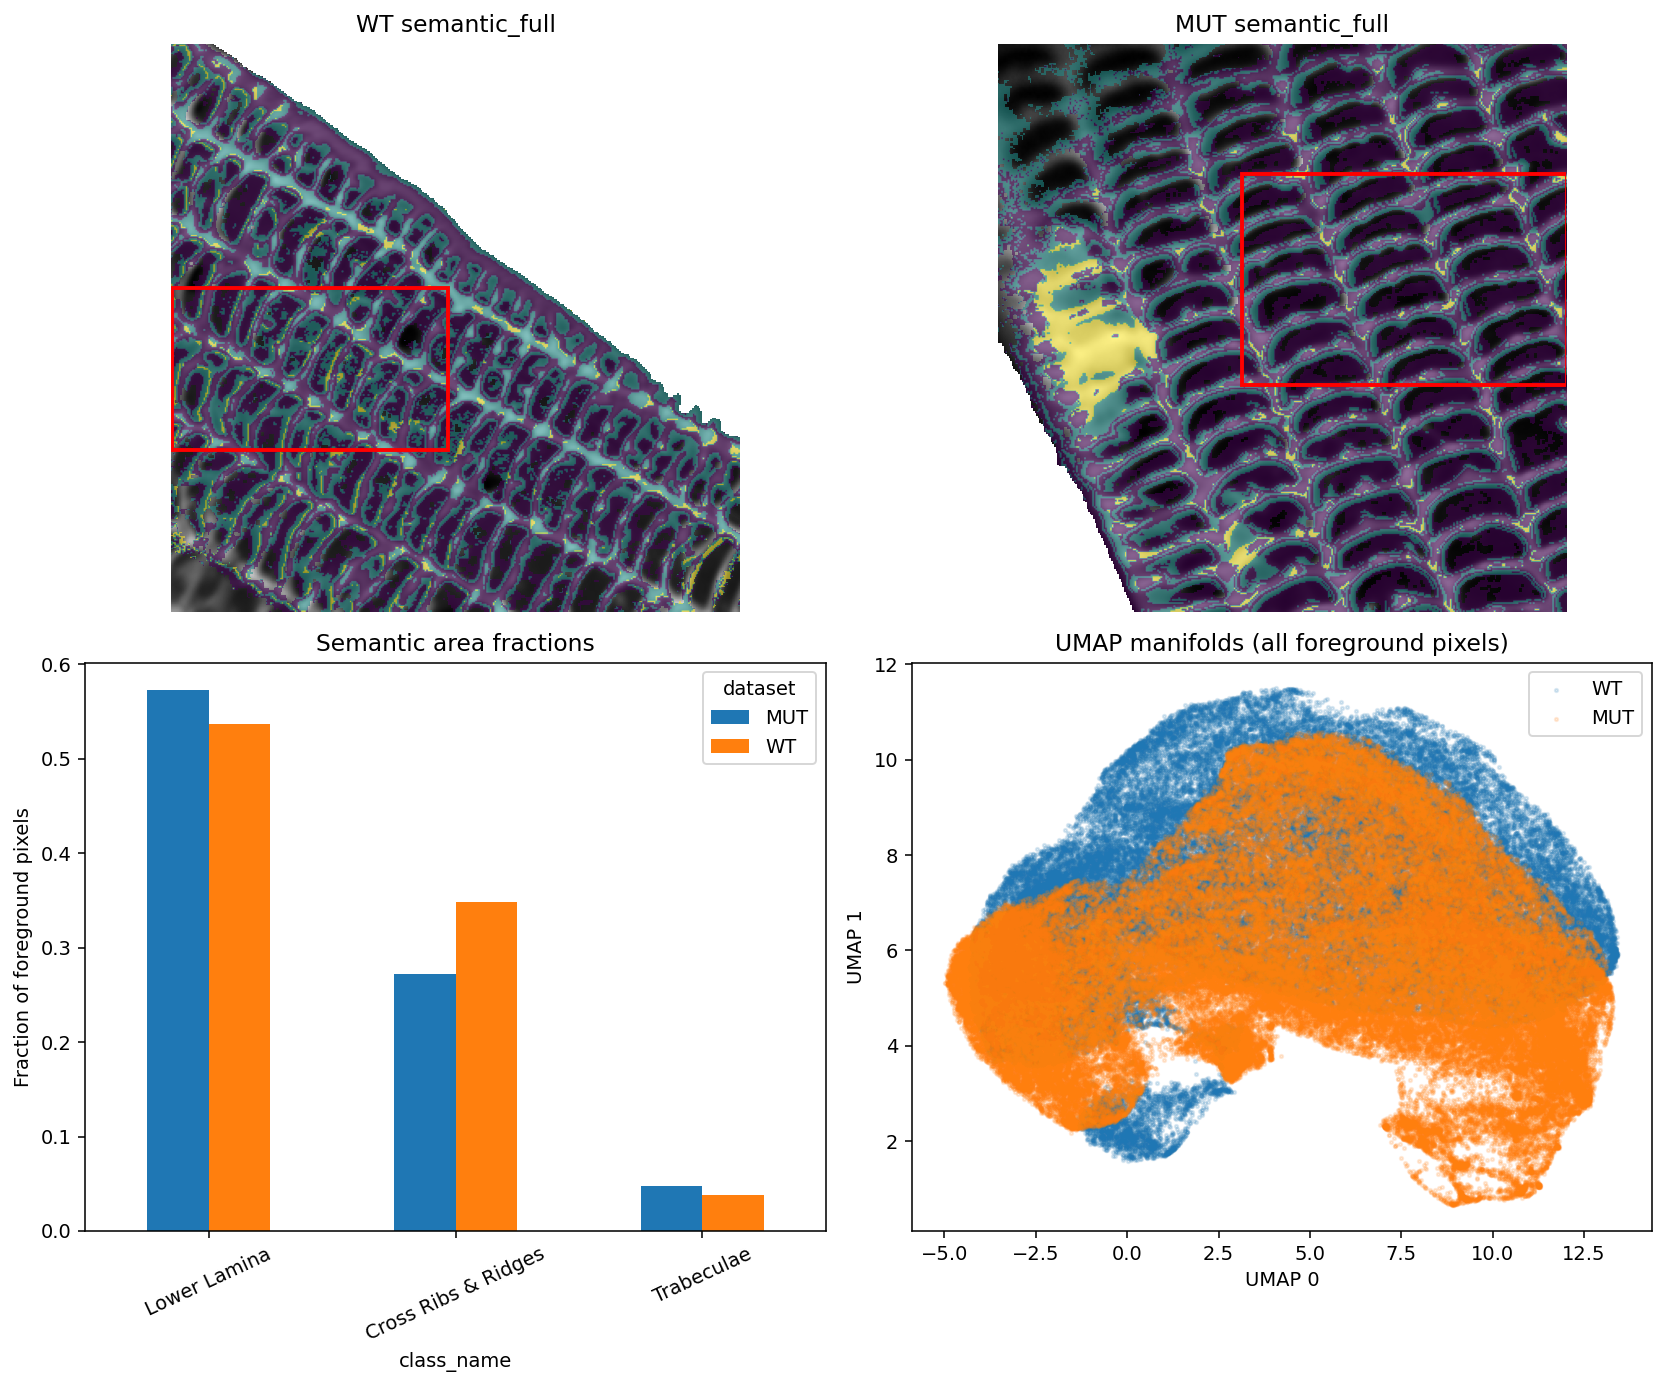

,dataset,class_id,class_name,pixels,fraction
0,WT,0,Lower Lamina,44931,0.537214
1,WT,1,Cross Ribs & Ridges,29127,0.348255
2,WT,2,Trabeculae,3221,0.038512
3,MUT,0,Lower Lamina,66082,0.573046
4,MUT,1,Cross Ribs & Ridges,31410,0.272380
5,MUT,2,Trabeculae,5537,0.048015


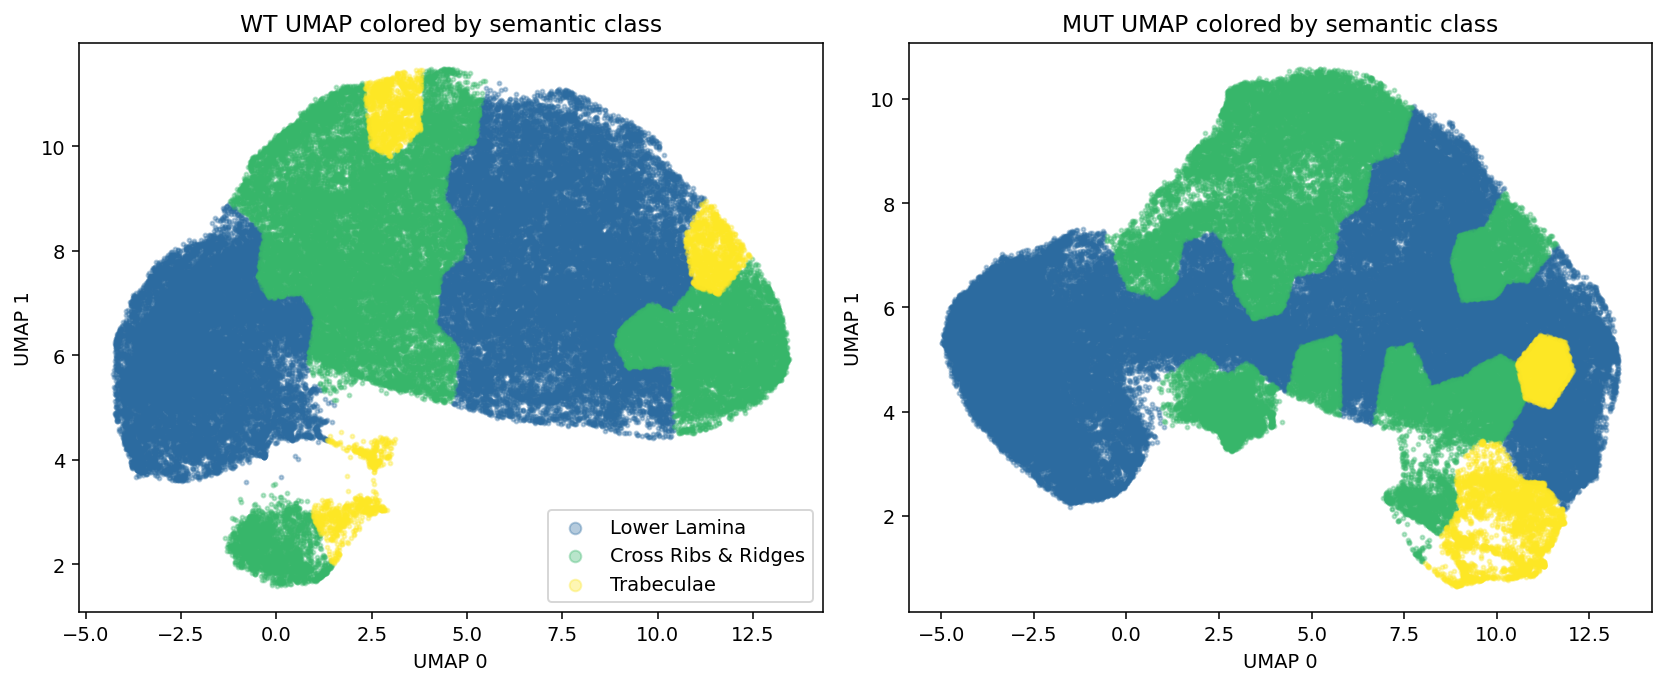

In [20]:
# Structure comparison: semantic maps, area fractions, and clustering manifolds
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=140)
for ax, name in zip(axes[0], ["WT", "MUT"]):
    data = datasets[name]
    show = data["semantic_full"].astype(float)
    show[show < 0] = np.nan
    ax.imshow(data["avg_absorbance"], cmap="gray")
    ax.imshow(show, cmap="viridis", alpha=0.55, vmin=0, vmax=2)
    x1, x2, y1, y2 = data["roi"]
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2))
    ax.set_title(f"{name} semantic_full")
    ax.axis("off")

fraction_df = semantic_fraction_table(datasets)
fraction_pivot = fraction_df.pivot(index="class_name", columns="dataset", values="fraction").loc[list(CLASS_NAMES.values())]
fraction_pivot.plot(kind="bar", ax=axes[1, 0], color=["tab:blue", "tab:orange"])
axes[1, 0].set_ylabel("Fraction of foreground pixels")
axes[1, 0].set_title("Semantic area fractions")
axes[1, 0].tick_params(axis="x", rotation=25)

for name, color in [("WT", "tab:blue"), ("MUT", "tab:orange")]:
    emb = datasets[name]["umap_embedding"]
    axes[1, 1].scatter(emb[:, 0], emb[:, 1], s=3, alpha=0.15, color=color, label=name)
axes[1, 1].set_title("UMAP manifolds (all foreground pixels)")
axes[1, 1].set_xlabel("UMAP 0")
axes[1, 1].set_ylabel("UMAP 1")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

display(fraction_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=140)
colors = {0: "#2C6BA0", 1: "#37B66A", 2: "#FDE725"}
for ax, name in zip(axes, ["WT", "MUT"]):
    data = datasets[name]
    valid_mask = data.get("cluster_valid_mask")
    if valid_mask is None:
        valid_mask = data["cluster_labels_full"] >= 0
    labels = data["semantic_full"].reshape(-1)[valid_mask.reshape(-1)]
    emb = data["umap_embedding"]
    n = min(len(labels), len(emb))
    labels = labels[:n]
    emb = emb[:n]
    for class_id, class_name in CLASS_NAMES.items():
        m = labels == class_id
        ax.scatter(emb[m, 0], emb[m, 1], s=4, alpha=0.35, color=colors[class_id], label=class_name)
    ax.set_title(f"{name} UMAP colored by semantic class")
    ax.set_xlabel("UMAP 0")
    ax.set_ylabel("UMAP 1")
axes[0].legend(markerscale=3)
plt.tight_layout()
plt.show()

In [21]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.10):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class SpectralMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim=512, num_blocks=6, dropout=0.10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.ModuleList([ResidualBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)])
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(0.05),
            nn.Linear(192, out_dim),
        )

    def forward(self, x):
        x = self.stem(x)
        for block in self.blocks:
            x = block(x)
        return self.head(x)


def normalize_sin_cos(out, d):
    sin_pred = out[:, :d]
    cos_pred = out[:, d:]
    norm = torch.sqrt(sin_pred ** 2 + cos_pred ** 2 + 1e-8)
    return sin_pred / norm, cos_pred / norm


def weighted_sc_loss(out, target, sample_w, d):
    sin_pred, cos_pred = normalize_sin_cos(out, d)
    sin_true = target[:, :d]
    cos_true = target[:, d:]
    loss_per_sample = (((sin_pred - sin_true) ** 2).mean(dim=1) + ((cos_pred - cos_true) ** 2).mean(dim=1)) / 2.0
    return (loss_per_sample * sample_w).sum() / sample_w.sum()


def angular_error(y_pred, y_true):
    return np.angle(np.exp(1j * (y_pred - y_true)))


def evaluate_phase(y_true, y_pred, name="set"):
    err = angular_error(y_pred, y_true)
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    cos_sim = np.mean(np.cos(err))
    r2 = r2_score(y_true.reshape(-1), y_pred.reshape(-1))
    return {
        "set": name,
        "angular_mae_rad": float(mae),
        "angular_rmse_rad": float(rmse),
        "mean_cos_error": float(cos_sim),
        "r2_supplementary": float(r2),
    }


def extract_last_latent(model, x_scaled, batch_size=4096, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    latents = []
    with torch.no_grad():
        for i in range(0, len(x_scaled), batch_size):
            xb = torch.from_numpy(x_scaled[i:i + batch_size].astype(np.float32)).to(device)
            x = model.stem(xb)
            for block in model.blocks:
                x = block(x)
            z = model.head[2](model.head[1](model.head[0](x)))
            latents.append(z.cpu().numpy())
    return np.vstack(latents)


def predict_phase(model, x_scaled, phase_ref, d, batch_size=4096, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(x_scaled), batch_size):
            xb = torch.from_numpy(x_scaled[i:i + batch_size].astype(np.float32)).to(device)
            out = model(xb)
            sin_pred, cos_pred = normalize_sin_cos(out, d)
            pred_res = np.arctan2(sin_pred.cpu().numpy(), cos_pred.cpu().numpy())
            pred_phase = np.angle(np.exp(1j * (pred_res + phase_ref[None, :])))
            preds.append(pred_phase)
    return np.vstack(preds)


def prepare_mlp_bundle(data, common_cfg):
    x1, x2, y1, y2 = data["roi"]
    x_abs_cube = data["abs_interp"][:, y1:y2, x1:x2].astype(np.float32)
    y_phase_cube = data["phase_interp"][:, y1:y2, x1:x2].astype(np.float32)
    cls_cube = data["semantic_roi"].astype(np.int32)

    d, h, w = x_abs_cube.shape
    n_total = h * w
    x_abs_full = x_abs_cube.transpose(1, 2, 0).reshape(n_total, d)
    y_phase_full = y_phase_cube.transpose(1, 2, 0).reshape(n_total, d)
    cls_full = cls_cube.reshape(-1)

    valid = np.all(np.isfinite(x_abs_full), axis=1) & np.all(np.isfinite(y_phase_full), axis=1) & (cls_full >= 0)
    x_abs_valid = x_abs_full[valid]
    y_phase_valid = y_phase_full[valid]
    cls_valid = cls_full[valid]

    if np.sum(cls_valid == 0) > 20:
        ref_mask = cls_valid == 0
        ref_name = "Lower Lamina"
    else:
        ref_mask = np.ones(len(x_abs_valid), dtype=bool)
        ref_name = "global mean"

    phase_ref = circular_mean(y_phase_valid[ref_mask], axis=0)
    y_res = np.angle(np.exp(1j * (y_phase_valid - phase_ref[None, :])))
    y_target = np.hstack([np.sin(y_res), np.cos(y_res)]).astype(np.float32)

    indices = np.arange(len(x_abs_valid))
    unique_cls, cls_counts = np.unique(cls_valid, return_counts=True)
    stratify_labels = cls_valid if (len(unique_cls) > 1 and np.min(cls_counts) >= 2) else None
    train_idx, val_idx = train_test_split(
        indices,
        test_size=common_cfg["test_size"],
        random_state=SEED,
        stratify=stratify_labels,
    )

    x_train = x_abs_valid[train_idx]
    x_val = x_abs_valid[val_idx]
    y_train = y_target[train_idx]
    y_val = y_target[val_idx]
    y_phase_val = y_phase_valid[val_idx]
    cls_train = cls_valid[train_idx]
    cls_val = cls_valid[val_idx]

    x_scaler = StandardScaler()
    x_train_s = x_scaler.fit_transform(x_train).astype(np.float32)
    x_val_s = x_scaler.transform(x_val).astype(np.float32)

    unique_cls, counts = np.unique(cls_train, return_counts=True)
    cls_count_dict = {c: n for c, n in zip(unique_cls, counts)}
    sample_weights_train = np.array([1.0 / cls_count_dict[c] for c in cls_train], dtype=np.float32)
    sample_weights_train *= len(sample_weights_train) / sample_weights_train.sum()
    sample_weights_val = np.ones(len(x_val_s), dtype=np.float32)

    bundle = {
        "dataset_name": data["name"],
        "d": d,
        "ref_name": ref_name,
        "phase_ref": phase_ref.astype(np.float32),
        "x_scaler": x_scaler,
        "x_train_s": x_train_s,
        "x_val_s": x_val_s,
        "y_train": y_train,
        "y_val": y_val,
        "y_phase_val": y_phase_val,
        "cls_train": cls_train,
        "cls_val": cls_val,
        "sample_weights_train": sample_weights_train,
        "sample_weights_val": sample_weights_val,
    }
    return bundle


def train_mlp_bundle(bundle, common_cfg):
    train_ds = TensorDataset(
        torch.from_numpy(bundle["x_train_s"]),
        torch.from_numpy(bundle["y_train"]),
        torch.from_numpy(bundle["sample_weights_train"]),
    )
    val_ds = TensorDataset(
        torch.from_numpy(bundle["x_val_s"]),
        torch.from_numpy(bundle["y_val"]),
        torch.from_numpy(bundle["sample_weights_val"]),
    )

    train_loader = DataLoader(train_ds, batch_size=common_cfg["batch_size"], shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=common_cfg["batch_size"], shuffle=False, drop_last=False)

    model = SpectralMLP(
        in_dim=bundle["x_train_s"].shape[1],
        out_dim=2 * bundle["d"],
        hidden_dim=common_cfg["hidden_dim"],
        num_blocks=common_cfg["num_blocks"],
        dropout=common_cfg["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=common_cfg["lr"], weight_decay=common_cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    best_val = np.inf
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, common_cfg["max_epochs"] + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0
        for xb, yb, wb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = weighted_sc_loss(out, yb, wb, bundle["d"])
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * len(xb)
            train_n += len(xb)
        train_loss = train_loss_sum / train_n

        model.eval()
        val_loss_sum = 0.0
        val_n = 0
        with torch.no_grad():
            for xb, yb, wb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                wb = wb.to(device)
                out = model(xb)
                loss = weighted_sc_loss(out, yb, wb, bundle["d"])
                val_loss_sum += loss.item() * len(xb)
                val_n += len(xb)
        val_loss = val_loss_sum / val_n
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= common_cfg["patience"]:
                break

    model.load_state_dict(best_state)

    y_val_pred = predict_phase(model, bundle["x_val_s"], bundle["phase_ref"], bundle["d"], device=device)
    rows = [evaluate_phase(bundle["y_phase_val"], y_val_pred, name=f"{bundle['dataset_name']} Validation")]
    for class_id in np.unique(bundle["cls_val"]):
        m = bundle["cls_val"] == class_id
        metrics_c = evaluate_phase(bundle["y_phase_val"][m], y_val_pred[m], name=CLASS_NAMES[int(class_id)])
        metrics_c["dataset"] = bundle["dataset_name"]
        metrics_c["class_id"] = int(class_id)
        metrics_c["class_name"] = CLASS_NAMES[int(class_id)]
        metrics_c["n_pixels"] = int(m.sum())
        rows.append(metrics_c)

    bundle["model"] = model
    bundle["history_df"] = pd.DataFrame(history)
    bundle["validation_metrics_df"] = pd.DataFrame(rows)
    bundle["latent_val"] = extract_last_latent(model, bundle["x_val_s"], device=device)
    bundle["latent_val_2d"] = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric="euclidean", random_state=SEED).fit_transform(bundle["latent_val"])
    return bundle


def evaluate_bundle_on_mask(bundle, target_data, mask, eval_name):
    x_abs_cube = target_data["abs_interp"]
    y_phase_cube = target_data["phase_interp"]
    semantic_full = target_data["semantic_full"]

    d, h, w = x_abs_cube.shape
    x_abs_full = x_abs_cube.transpose(1, 2, 0).reshape(h * w, d)
    y_phase_full = y_phase_cube.transpose(1, 2, 0).reshape(h * w, d)
    cls_full = semantic_full.reshape(-1)
    mask_flat = mask.reshape(-1)

    valid = mask_flat & np.all(np.isfinite(x_abs_full), axis=1) & np.all(np.isfinite(y_phase_full), axis=1) & (cls_full >= 0)
    x_valid = x_abs_full[valid].astype(np.float32)
    y_phase_valid = y_phase_full[valid]
    cls_valid = cls_full[valid]

    if len(x_valid) == 0:
        return {
            "metrics_df": pd.DataFrame(),
            "mae_map": np.full((h, w), np.nan, dtype=np.float32),
            "valid_mask": np.zeros((h, w), dtype=bool),
        }

    x_scaled = bundle["x_scaler"].transform(x_valid).astype(np.float32)
    y_pred = predict_phase(bundle["model"], x_scaled, bundle["phase_ref"], bundle["d"], device=device)

    rows = [evaluate_phase(y_phase_valid, y_pred, name=eval_name)]
    rows[0]["dataset"] = target_data["name"]
    rows[0]["source_model"] = bundle["dataset_name"]
    rows[0]["n_pixels"] = int(len(x_valid))
    for class_id in np.unique(cls_valid):
        m = cls_valid == class_id
        metrics_c = evaluate_phase(y_phase_valid[m], y_pred[m], name=f"{eval_name} | {CLASS_NAMES[int(class_id)]}")
        metrics_c["dataset"] = target_data["name"]
        metrics_c["source_model"] = bundle["dataset_name"]
        metrics_c["class_id"] = int(class_id)
        metrics_c["class_name"] = CLASS_NAMES[int(class_id)]
        metrics_c["n_pixels"] = int(m.sum())
        rows.append(metrics_c)

    err = angular_error(y_pred, y_phase_valid)
    mae_per_pixel = np.mean(np.abs(err), axis=1)
    mae_map = np.full(h * w, np.nan, dtype=np.float32)
    mae_map[valid] = mae_per_pixel
    mae_map = mae_map.reshape(h, w)

    return {
        "metrics_df": pd.DataFrame(rows),
        "mae_map": mae_map,
        "valid_mask": valid.reshape(h, w),
    }

Preparing ROI training bundle for WT ...
Training MLP for WT with reference: Lower Lamina
Preparing ROI training bundle for MUT ...
Training MLP for MUT with reference: Lower Lamina


,set,angular_mae_rad,angular_rmse_rad,mean_cos_error,r2_supplementary,dataset,class_id,class_name,n_pixels
0,WT Validation,0.052887,0.092151,0.996093,0.807459,NaN,NaN,NaN,NaN
1,Lower Lamina,0.049215,0.070943,0.997493,0.952328,WT,0.0,Lower Lamina,1898.0
2,Cross Ribs & Ridges,0.058566,0.118361,0.993867,0.657839,WT,1.0,Cross Ribs & Ridges,1266.0
3,Trabeculae,0.051442,0.075692,0.997147,0.788854,WT,2.0,Trabeculae,152.0
4,MUT Validation,0.097314,0.232967,0.979083,0.497823,NaN,NaN,NaN,NaN
5,Lower Lamina,0.097957,0.240854,0.977906,0.455588,MUT,0.0,Lower Lamina,3359.0
6,Cross Ribs & Ridges,0.090378,0.205277,0.983336,0.622733,MUT,1.0,Cross Ribs & Ridges,1243.0
7,Trabeculae,0.160039,0.280771,0.966153,0.304272,MUT,2.0,Trabeculae,103.0


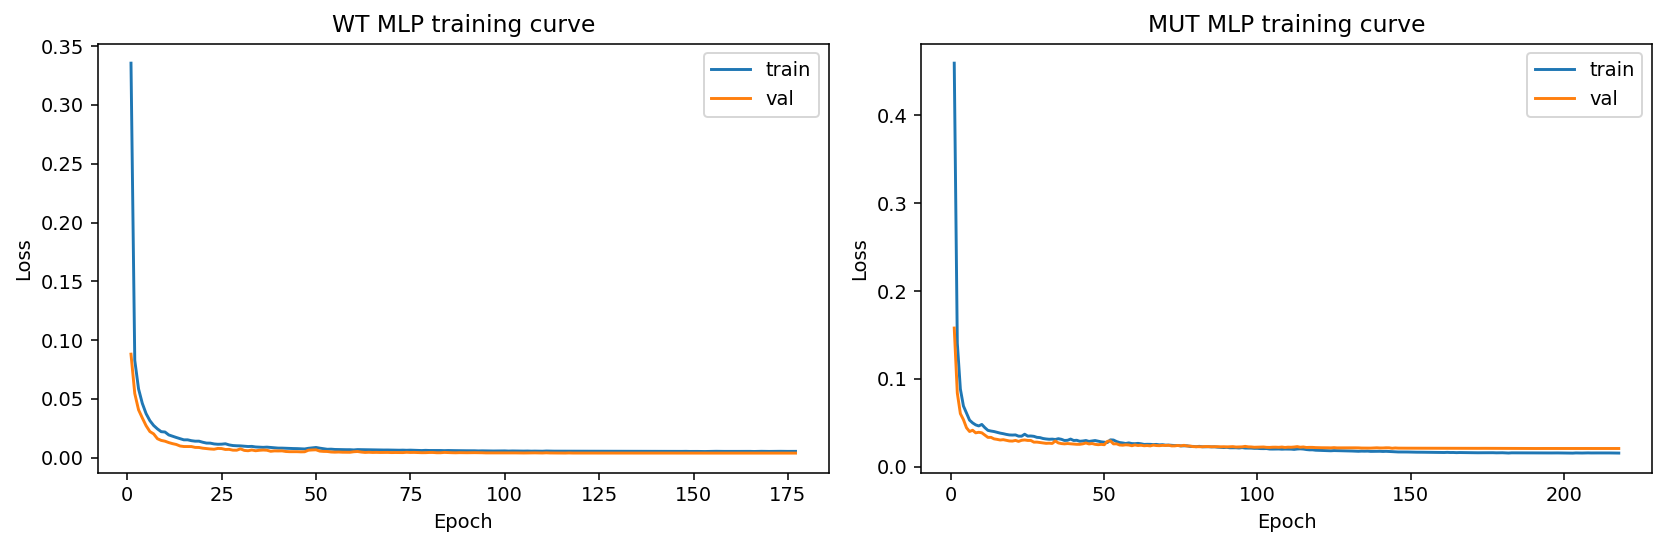

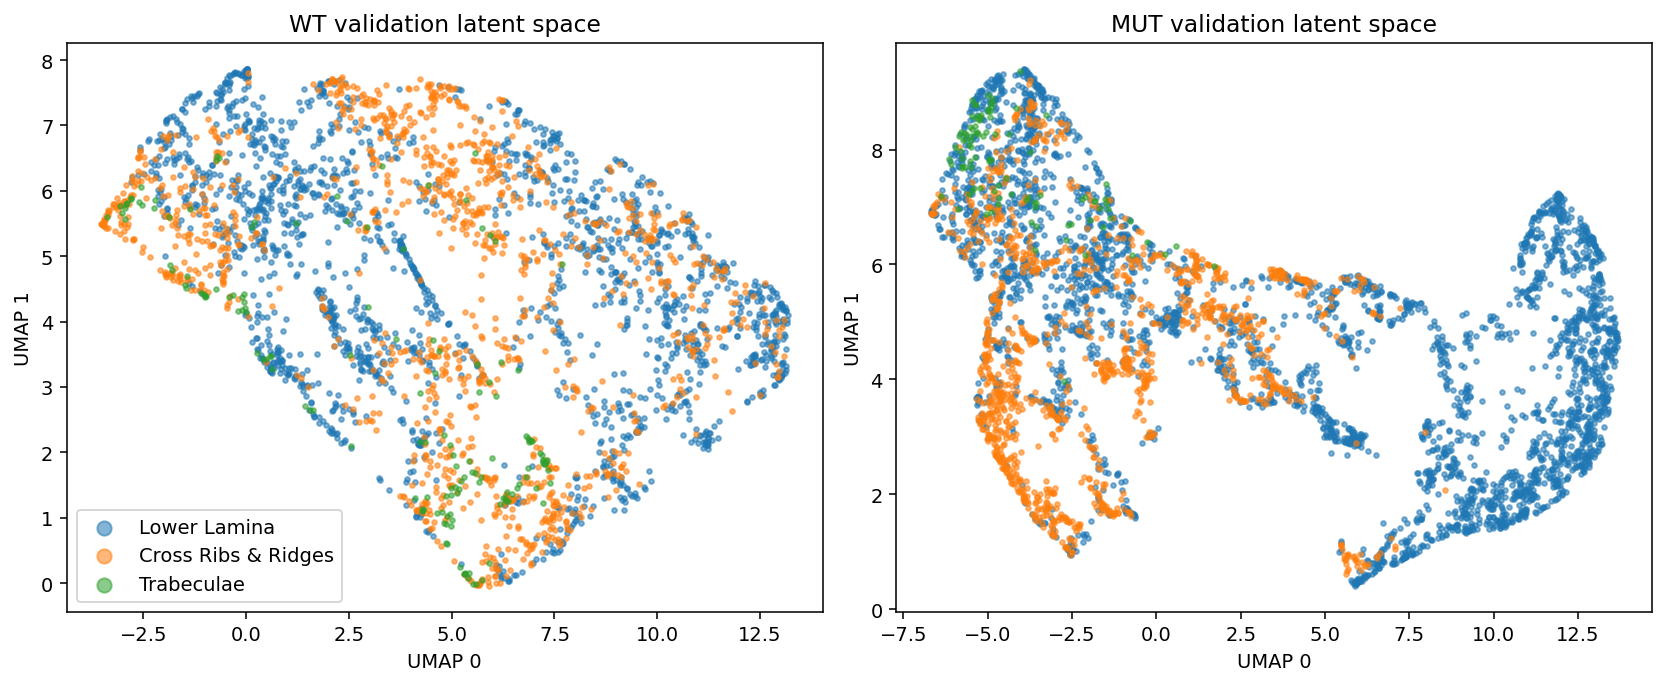

In [22]:
mlp_bundles = {}
for name in ["WT", "MUT"]:
    print(f"Preparing ROI training bundle for {name} ...")
    bundle = prepare_mlp_bundle(datasets[name], COMMON_CFG)
    print(f"Training MLP for {name} with reference: {bundle['ref_name']}")
    bundle = train_mlp_bundle(bundle, COMMON_CFG)
    mlp_bundles[name] = bundle

validation_metrics_df = pd.concat(
    [mlp_bundles["WT"]["validation_metrics_df"], mlp_bundles["MUT"]["validation_metrics_df"]],
    ignore_index=True,
)
display(validation_metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)
for ax, name in zip(axes, ["WT", "MUT"]):
    hist = mlp_bundles[name]["history_df"]
    ax.plot(hist["epoch"], hist["train_loss"], label="train")
    ax.plot(hist["epoch"], hist["val_loss"], label="val")
    ax.set_title(f"{name} MLP training curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=140)
for ax, name in zip(axes, ["WT", "MUT"]):
    bundle = mlp_bundles[name]
    for class_id, class_name in CLASS_NAMES.items():
        m = bundle["cls_val"] == class_id
        ax.scatter(
            bundle["latent_val_2d"][m, 0],
            bundle["latent_val_2d"][m, 1],
            s=6,
            alpha=0.55,
            label=class_name,
        )
    ax.set_title(f"{name} validation latent space")
    ax.set_xlabel("UMAP 0")
    ax.set_ylabel("UMAP 1")
axes[0].legend(markerscale=3)
plt.tight_layout()
plt.show()

,set,angular_mae_rad,angular_rmse_rad,mean_cos_error,r2_supplementary,dataset,source_model,n_pixels,class_id,class_name
0,WT -> WT test mask,0.099423,0.140460,0.990390,0.780133,WT,WT,14283,NaN,NaN
1,WT -> WT test mask | Lower Lamina,0.096704,0.131585,0.991442,0.878711,WT,WT,8342,0.0,Lower Lamina
2,WT -> WT test mask | Cross Ribs & Ridges,0.102556,0.152232,0.988933,0.626568,WT,WT,5098,1.0,Cross Ribs & Ridges
3,WT -> WT test mask | Trabeculae,0.107381,0.150939,0.988788,0.734867,WT,WT,843,2.0,Trabeculae
4,WT -> MUT test mask,0.214444,0.358358,0.946572,0.150935,MUT,WT,26388,NaN,NaN
5,WT -> MUT test mask | Lower Lamina,0.207312,0.365787,0.945974,0.104102,MUT,WT,19221,0.0,Lower Lamina
6,WT -> MUT test mask | Cross Ribs & Ridges,0.221121,0.318584,0.953541,0.376489,MUT,WT,6349,1.0,Cross Ribs & Ridges
7,WT -> MUT test mask | Trabeculae,0.330206,0.459338,0.906533,-0.039743,MUT,WT,818,2.0,Trabeculae
8,MUT -> MUT test mask,0.143725,0.295612,0.965339,0.267293,MUT,MUT,26388,NaN,NaN
9,MUT -> MUT test mask | Lower Lamina,0.146153,0.312182,0.962316,0.217958,MUT,MUT,19221,0.0,Lower Lamina


Shared MAE color scale vmax = 0.5198727


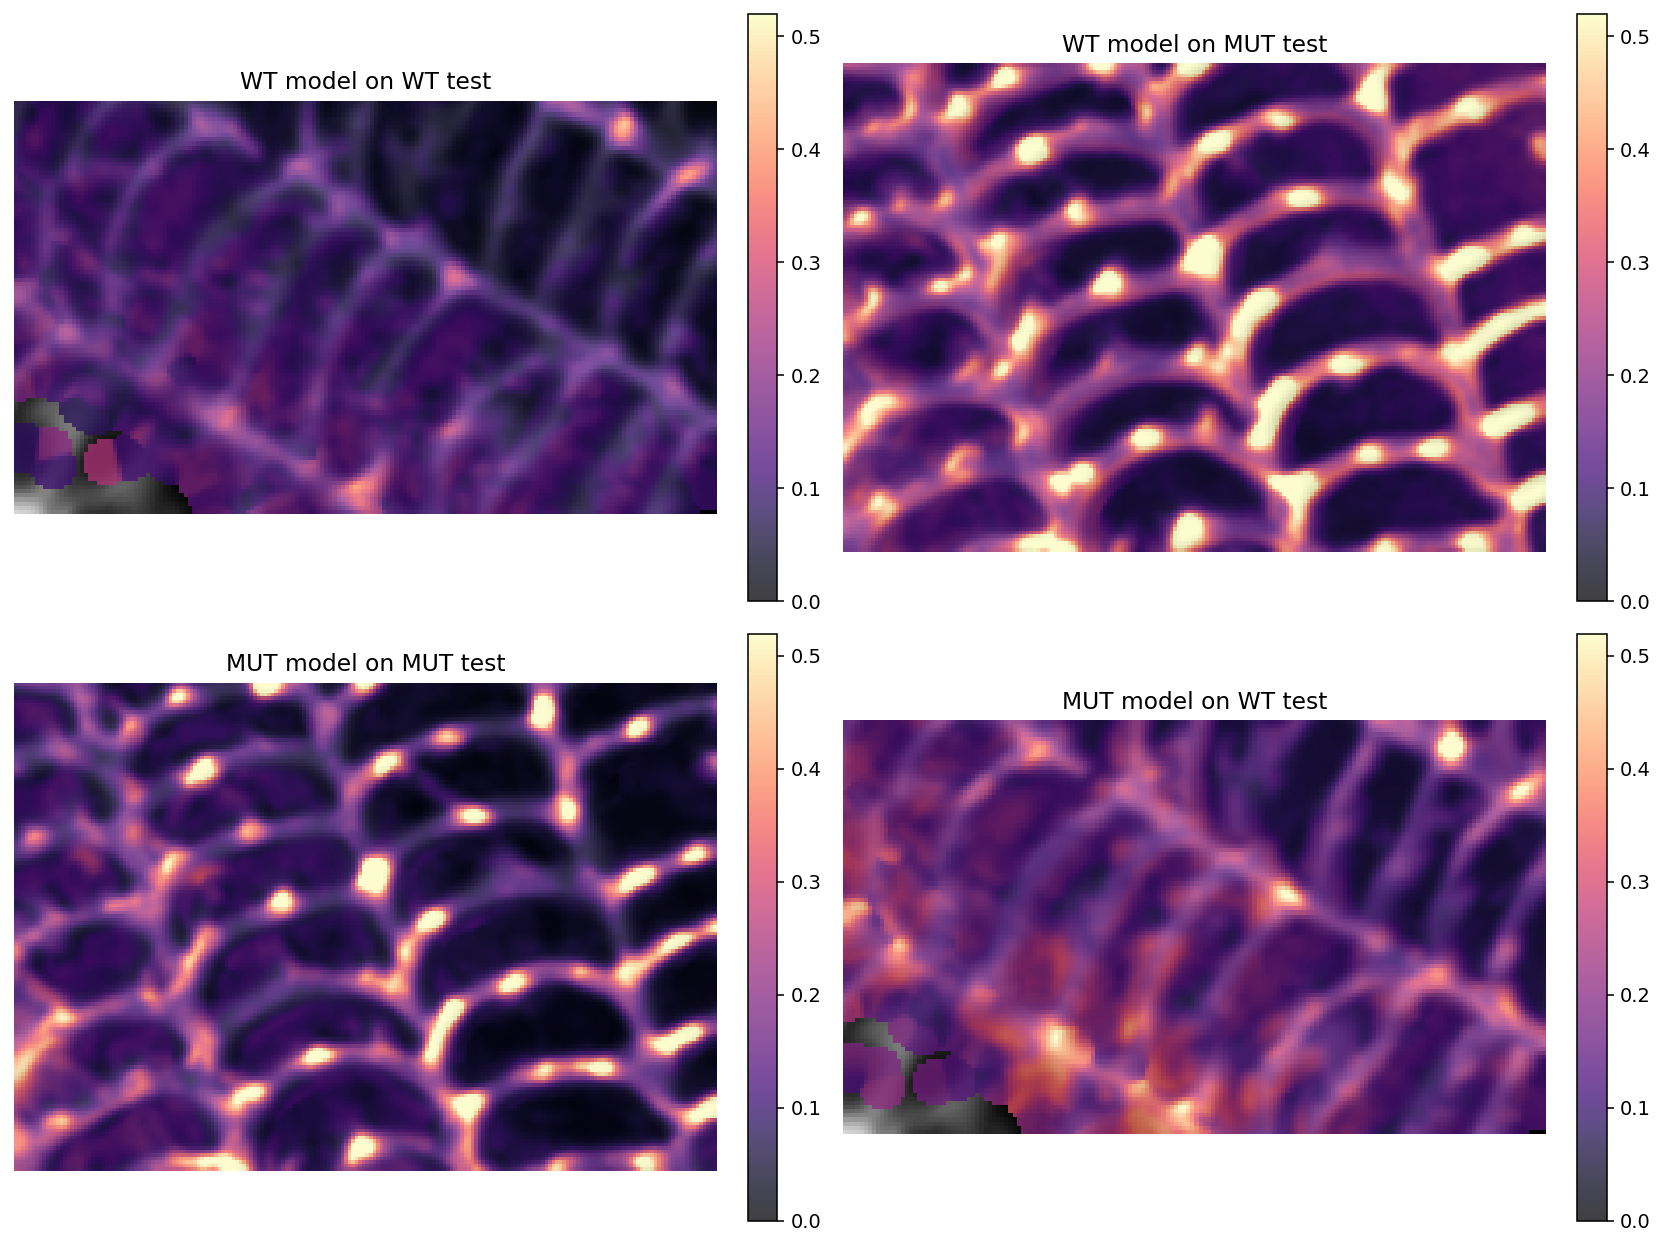

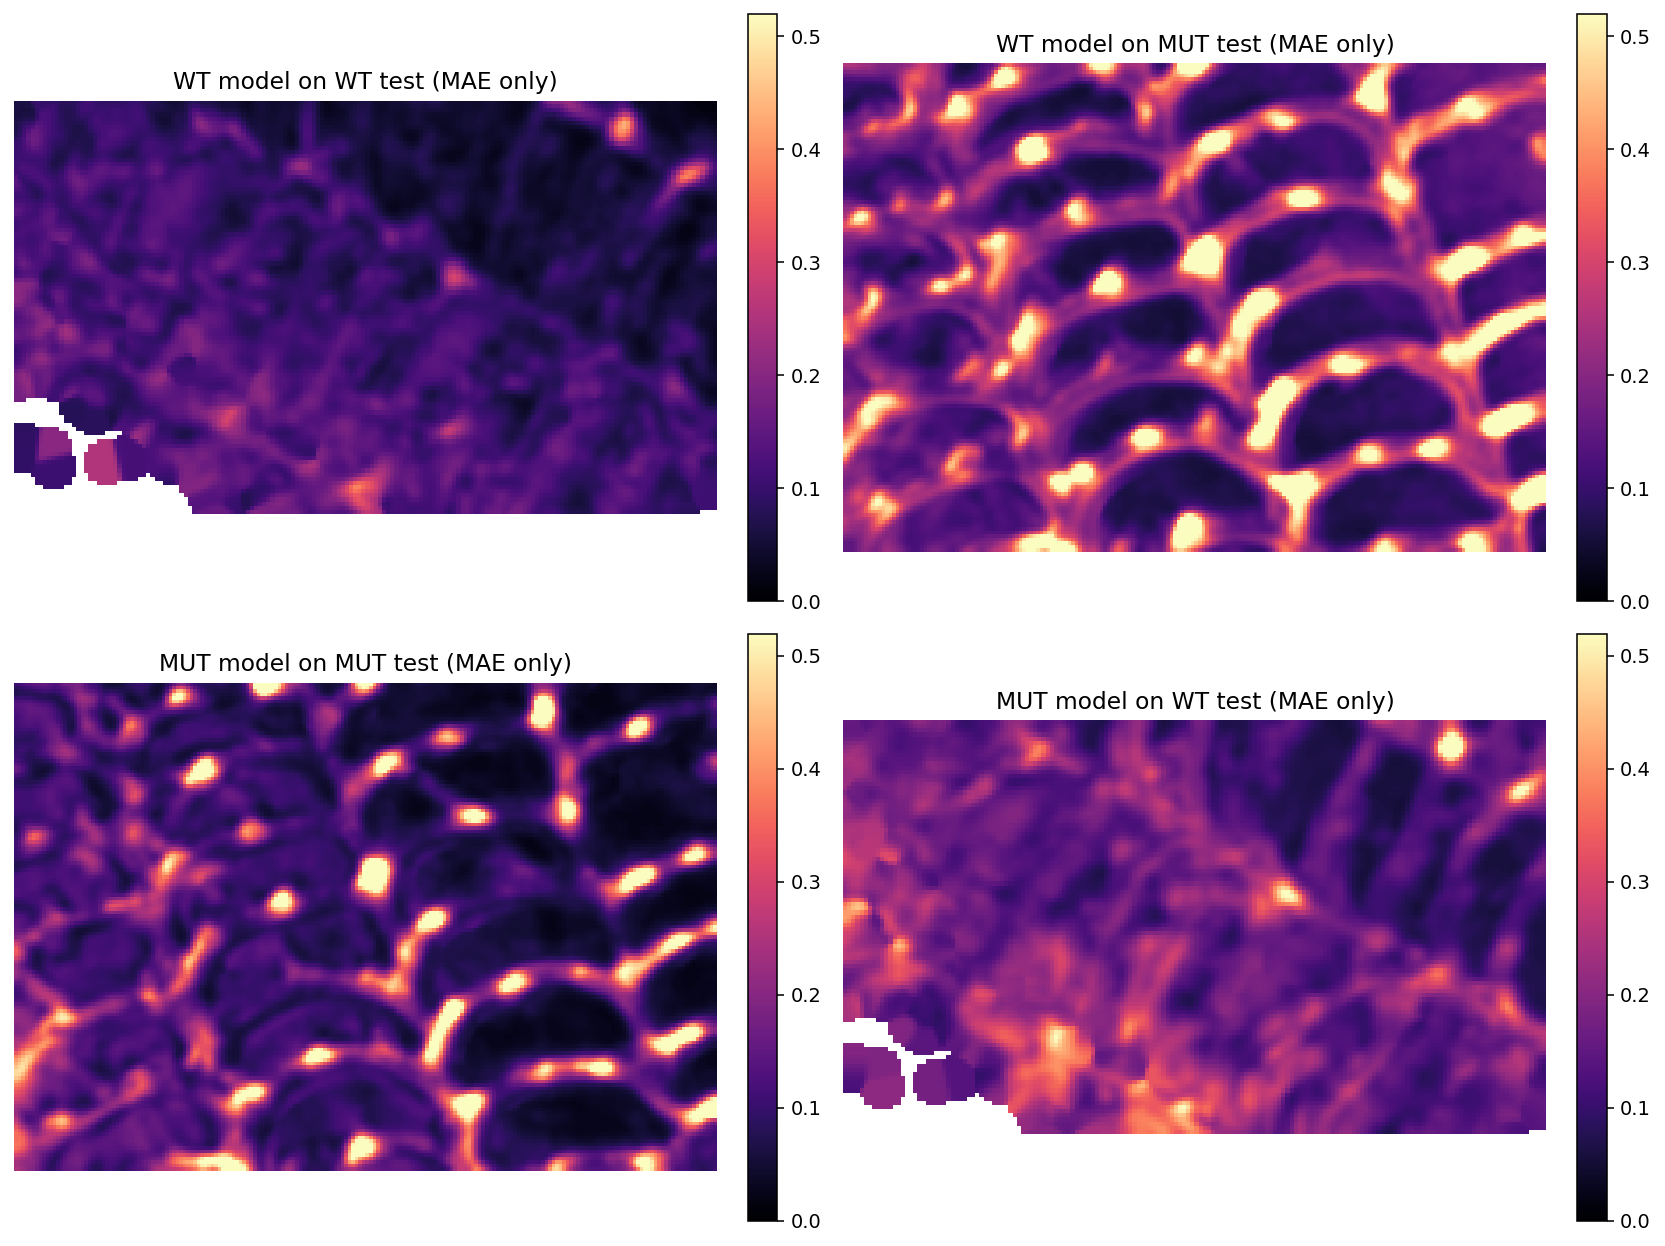

,source_model,self_target,cross_target,self_mae,cross_mae,delta_mae,self_rmse,cross_rmse,delta_rmse
0,WT,WT,MUT,0.099423,0.214444,0.115021,0.140460,0.358358,0.217898
1,MUT,MUT,WT,0.143725,0.170408,0.026682,0.295612,0.234643,-0.060968


,source_model,self_target,cross_target,class_id,class_name,self_mae,cross_mae,delta_mae,self_rmse,cross_rmse,delta_rmse
0,WT,WT,MUT,0,Lower Lamina,0.096704,0.207312,0.110609,0.131585,0.365787,0.234202
1,WT,WT,MUT,1,Cross Ribs & Ridges,0.102556,0.221121,0.118564,0.152232,0.318584,0.166352
2,WT,WT,MUT,2,Trabeculae,0.107381,0.330206,0.222824,0.150939,0.459338,0.308398
3,MUT,MUT,WT,0,Lower Lamina,0.146153,0.166147,0.019994,0.312182,0.224645,-0.087537
4,MUT,MUT,WT,1,Cross Ribs & Ridges,0.121180,0.171033,0.049853,0.214174,0.243327,0.029153
5,MUT,MUT,WT,2,Trabeculae,0.261683,0.208786,-0.052897,0.415879,0.274585,-0.141294


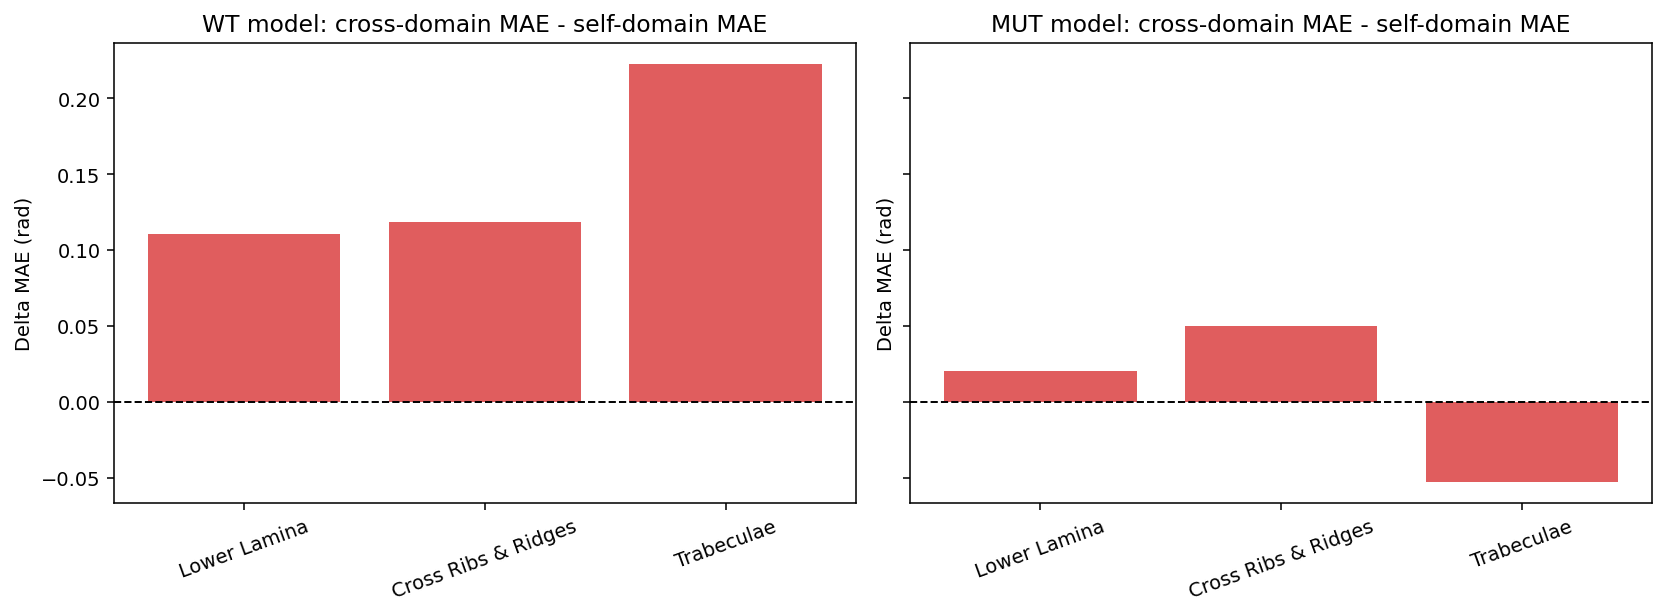

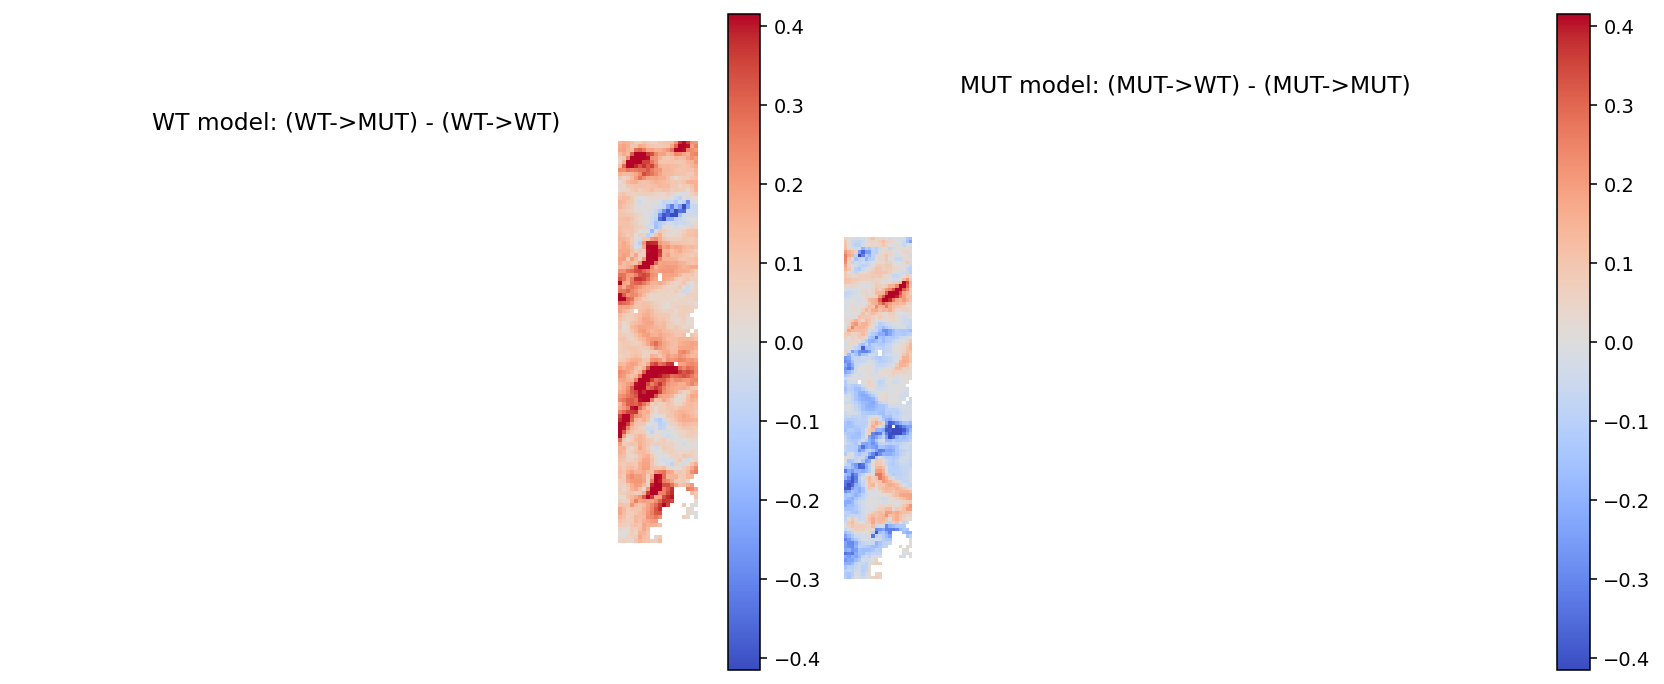

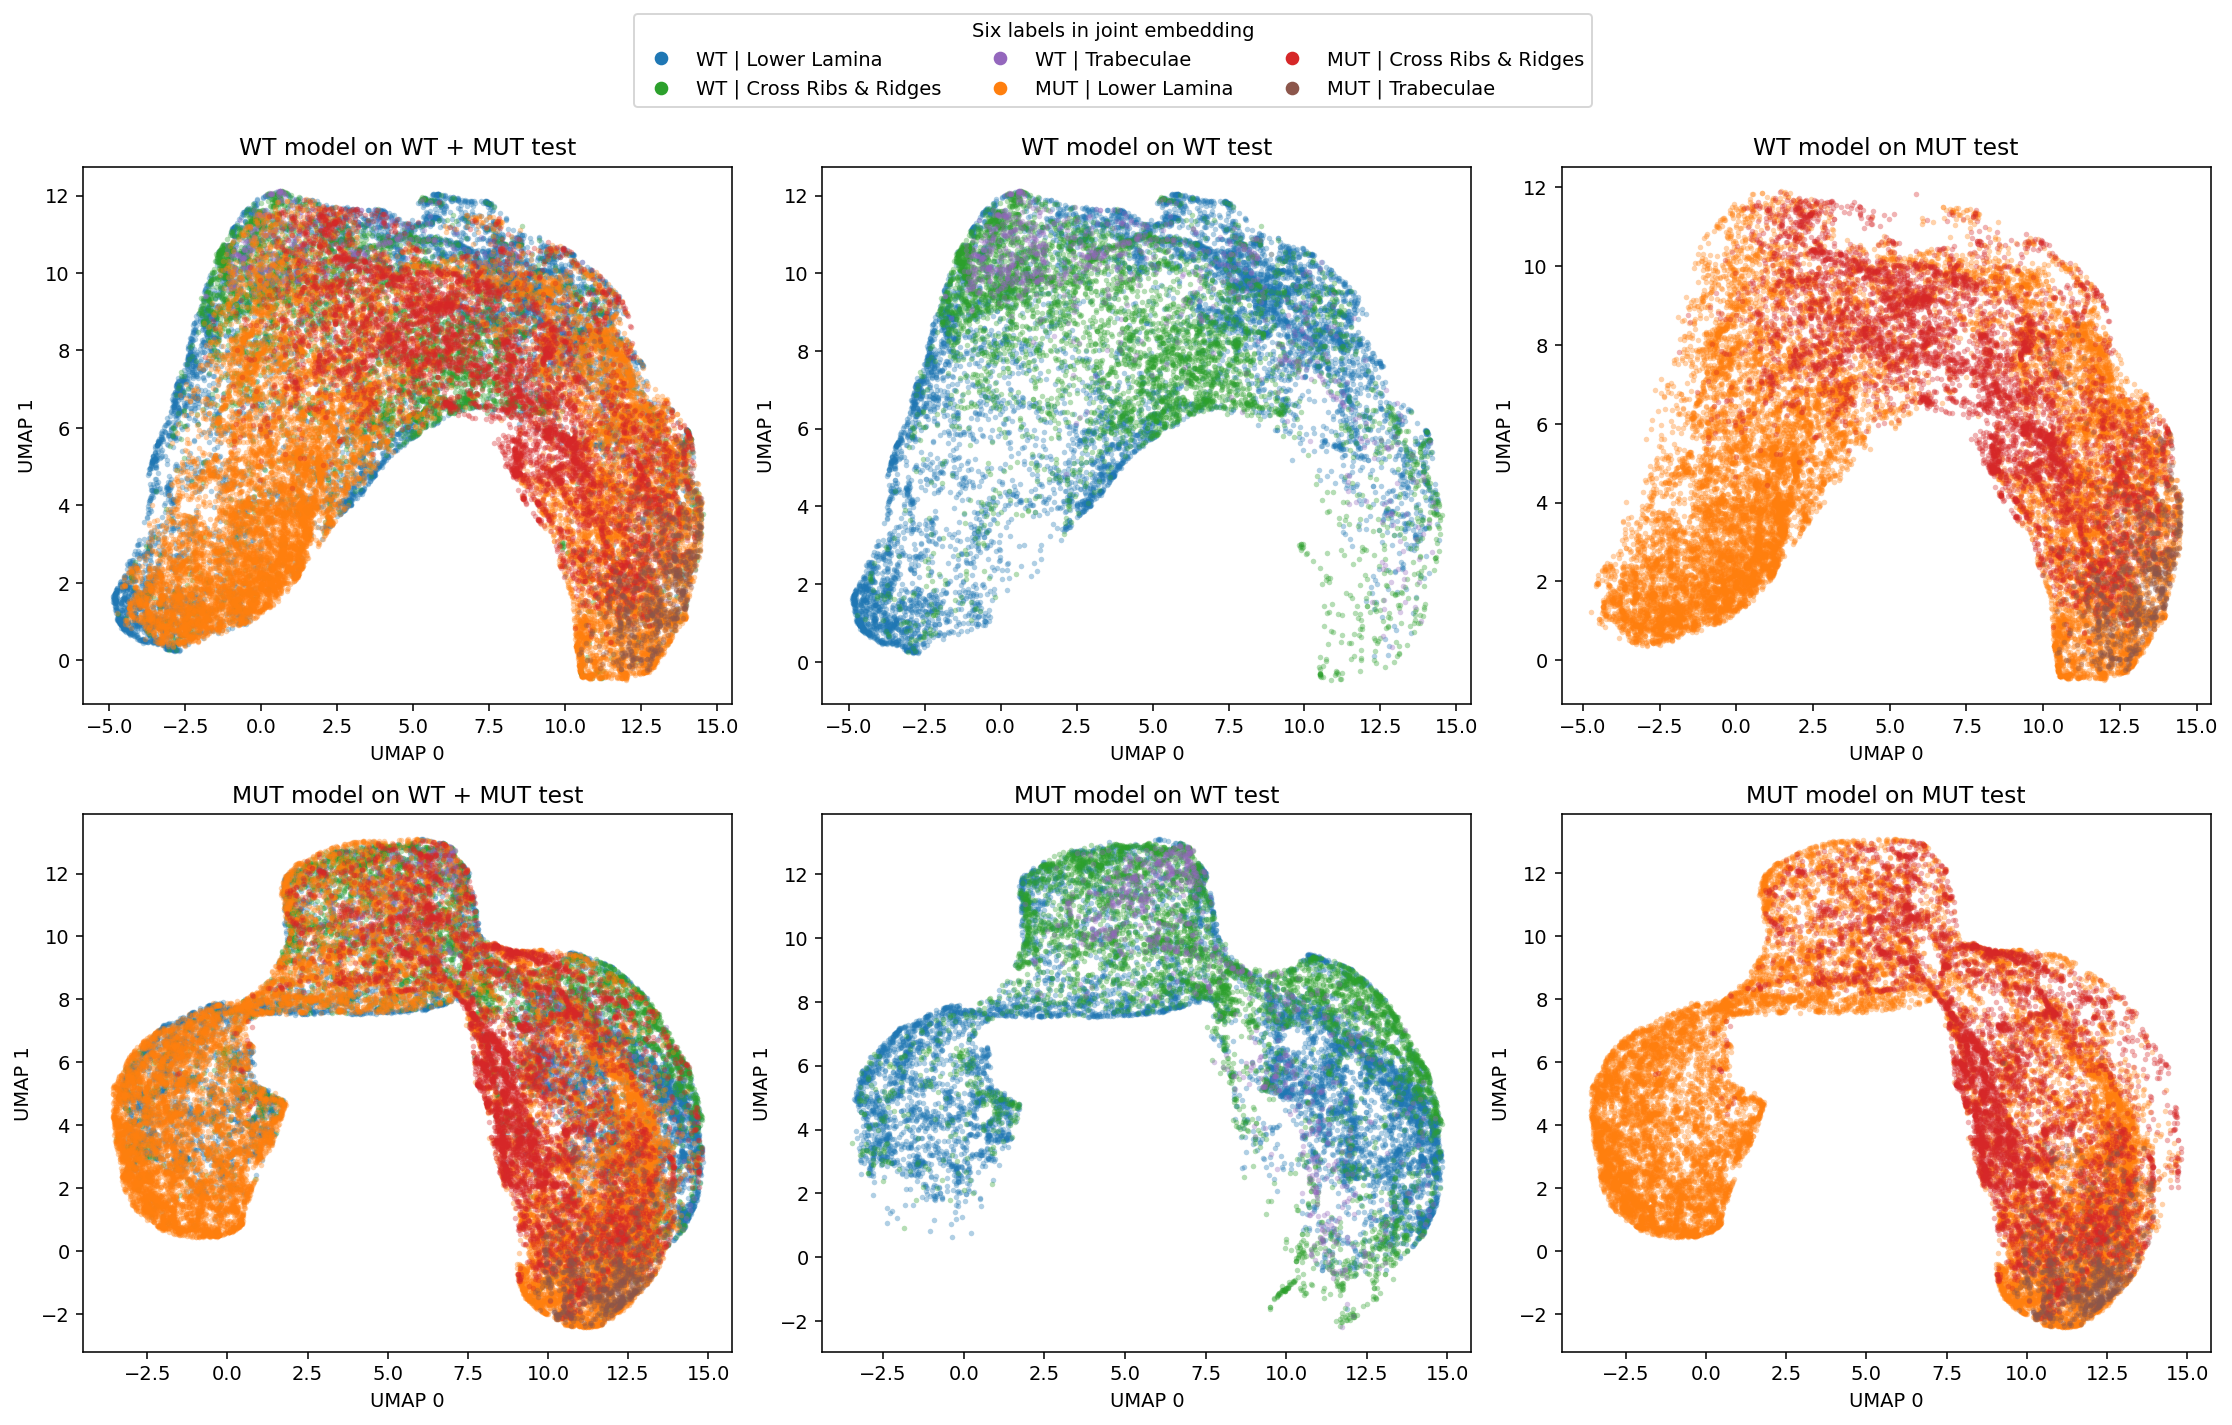

In [23]:
cross_results = {}
for source_name, target_name in [("WT", "WT"), ("WT", "MUT"), ("MUT", "MUT"), ("MUT", "WT")]:
    key = f"{source_name}_to_{target_name}"
    cross_results[key] = evaluate_bundle_on_mask(
        mlp_bundles[source_name],
        datasets[target_name],
        datasets[target_name]["test_mask"],
        eval_name=f"{source_name} -> {target_name} test mask",
    )

cross_metric_frames = [v["metrics_df"] for v in cross_results.values() if not v["metrics_df"].empty]
cross_metrics_df = pd.concat(cross_metric_frames, ignore_index=True) if cross_metric_frames else pd.DataFrame()
display(cross_metrics_df)

plot_order = [
    ("WT_to_WT", "WT model on WT test"),
    ("WT_to_MUT", "WT model on MUT test"),
    ("MUT_to_MUT", "MUT model on MUT test"),
    ("MUT_to_WT", "MUT model on WT test"),
]

# --------------------------------------------------
# 1) Build comparable maps and use a shared color scale
# --------------------------------------------------
plot_cache = {}
global_vmax = 0.0

for key, title in plot_order:
    target_name = key.split("_to_")[1]
    base = datasets[target_name]["avg_absorbance"]
    mae_map = smooth_nan_map(cross_results[key]["mae_map"], sigma=1.2)
    plot_mask = datasets[target_name]["test_mask"]

    rows, cols = np.where(plot_mask)
    r0, r1 = rows.min(), rows.max() + 1
    c0, c1 = cols.min(), cols.max() + 1

    base_plot = np.where(plot_mask, base, np.nan)[r0:r1, c0:c1]
    mae_plot = np.where(plot_mask, mae_map, np.nan)[r0:r1, c0:c1]

    base_lo, base_hi = robust_range(base_plot, 2, 98)

    local_vals = mae_plot[np.isfinite(mae_plot)]
    if local_vals.size > 0:
        local_vmax = np.nanpercentile(local_vals, 95)
        global_vmax = max(global_vmax, local_vmax)

    plot_cache[key] = {
        "title": title,
        "base_plot": base_plot,
        "mae_plot": mae_plot,
        "base_lo": base_lo,
        "base_hi": base_hi,
        "crop": (r0, r1, c0, c1),
    }

print("Shared MAE color scale vmax =", global_vmax)

# --------------------------------------------------
# 2) Overlay maps with shared color scale
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=140)

for ax, (key, title) in zip(axes.ravel(), plot_order):
    item = plot_cache[key]

    ax.imshow(item["base_plot"], cmap="gray", vmin=item["base_lo"], vmax=item["base_hi"])
    im = ax.imshow(item["mae_plot"], cmap="magma", alpha=0.75, vmin=0, vmax=global_vmax)

    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3) Pure MAE maps with shared color scale
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=140)

for ax, (key, title) in zip(axes.ravel(), plot_order):
    item = plot_cache[key]

    im = ax.imshow(item["mae_plot"], cmap="magma", vmin=0, vmax=global_vmax)
    ax.set_title(f"{title} (MAE only)")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4) Cross-domain degradation summary
# cross-domain error minus self-domain error
# --------------------------------------------------
def get_metric_row(df, set_name):
    row = df[df["set"] == set_name]
    if len(row) == 0:
        return None
    return row.iloc[0]

summary_rows = []

# WT model: compare WT->MUT against WT->WT
wt_self = get_metric_row(cross_results["WT_to_WT"]["metrics_df"], "WT -> WT test mask")
wt_cross = get_metric_row(cross_results["WT_to_MUT"]["metrics_df"], "WT -> MUT test mask")

if wt_self is not None and wt_cross is not None:
    summary_rows.append({
        "source_model": "WT",
        "self_target": "WT",
        "cross_target": "MUT",
        "self_mae": float(wt_self["angular_mae_rad"]),
        "cross_mae": float(wt_cross["angular_mae_rad"]),
        "delta_mae": float(wt_cross["angular_mae_rad"] - wt_self["angular_mae_rad"]),
        "self_rmse": float(wt_self["angular_rmse_rad"]),
        "cross_rmse": float(wt_cross["angular_rmse_rad"]),
        "delta_rmse": float(wt_cross["angular_rmse_rad"] - wt_self["angular_rmse_rad"]),
    })

# MUT model: compare MUT->WT against MUT->MUT
mut_self = get_metric_row(cross_results["MUT_to_MUT"]["metrics_df"], "MUT -> MUT test mask")
mut_cross = get_metric_row(cross_results["MUT_to_WT"]["metrics_df"], "MUT -> WT test mask")

if mut_self is not None and mut_cross is not None:
    summary_rows.append({
        "source_model": "MUT",
        "self_target": "MUT",
        "cross_target": "WT",
        "self_mae": float(mut_self["angular_mae_rad"]),
        "cross_mae": float(mut_cross["angular_mae_rad"]),
        "delta_mae": float(mut_cross["angular_mae_rad"] - mut_self["angular_mae_rad"]),
        "self_rmse": float(mut_self["angular_rmse_rad"]),
        "cross_rmse": float(mut_cross["angular_rmse_rad"]),
        "delta_rmse": float(mut_cross["angular_rmse_rad"] - mut_self["angular_rmse_rad"]),
    })

degradation_df = pd.DataFrame(summary_rows)
display(degradation_df)

# --------------------------------------------------
# 5) Per-class degradation
# --------------------------------------------------
per_class_rows = []

for source_name, self_key, cross_key, self_target, cross_target in [
    ("WT", "WT_to_WT", "WT_to_MUT", "WT", "MUT"),
    ("MUT", "MUT_to_MUT", "MUT_to_WT", "MUT", "WT"),
]:
    df_self = cross_results[self_key]["metrics_df"]
    df_cross = cross_results[cross_key]["metrics_df"]

    for class_id, class_name in CLASS_NAMES.items():
        row_self = df_self[df_self["class_name"] == class_name]
        row_cross = df_cross[df_cross["class_name"] == class_name]

        if len(row_self) == 0 or len(row_cross) == 0:
            continue

        row_self = row_self.iloc[0]
        row_cross = row_cross.iloc[0]

        per_class_rows.append({
            "source_model": source_name,
            "self_target": self_target,
            "cross_target": cross_target,
            "class_id": class_id,
            "class_name": class_name,
            "self_mae": float(row_self["angular_mae_rad"]),
            "cross_mae": float(row_cross["angular_mae_rad"]),
            "delta_mae": float(row_cross["angular_mae_rad"] - row_self["angular_mae_rad"]),
            "self_rmse": float(row_self["angular_rmse_rad"]),
            "cross_rmse": float(row_cross["angular_rmse_rad"]),
            "delta_rmse": float(row_cross["angular_rmse_rad"] - row_self["angular_rmse_rad"]),
        })

per_class_degradation_df = pd.DataFrame(per_class_rows)
display(per_class_degradation_df)

# --------------------------------------------------
# 6) Per-class degradation bar plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=140, sharey=True)

for ax, source_name in zip(axes, ["WT", "MUT"]):
    sub = per_class_degradation_df[per_class_degradation_df["source_model"] == source_name]

    ax.bar(sub["class_name"], sub["delta_mae"], color="tab:red", alpha=0.75)
    ax.axhline(0.0, color="black", lw=1, ls="--")
    ax.set_title(f"{source_name} model: cross-domain MAE - self-domain MAE")
    ax.set_ylabel("Delta MAE (rad)")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7) Pixel-wise degradation maps
# cross-domain MAE map minus self-domain MAE map
# --------------------------------------------------
degradation_maps = {
    "WT_model_cross_minus_self": cross_results["WT_to_MUT"]["mae_map"] - cross_results["WT_to_WT"]["mae_map"],
    "MUT_model_cross_minus_self": cross_results["MUT_to_WT"]["mae_map"] - cross_results["MUT_to_MUT"]["mae_map"],
}

all_vals = []
for arr in degradation_maps.values():
    vals = arr[np.isfinite(arr)]
    if vals.size > 0:
        all_vals.append(np.nanpercentile(np.abs(vals), 95))

delta_vmax = max(all_vals) if len(all_vals) > 0 else 0.1

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=140)

for ax, (key, arr) in zip(axes, degradation_maps.items()):
    if key.startswith("WT"):
        target_name = "WT"
        title = "WT model: (WT->MUT) - (WT->WT)"
    else:
        target_name = "MUT"
        title = "MUT model: (MUT->WT) - (MUT->MUT)"

    plot_mask = datasets[target_name]["test_mask"]
    rows, cols = np.where(plot_mask)
    r0, r1 = rows.min(), rows.max() + 1
    c0, c1 = cols.min(), cols.max() + 1

    delta_plot = np.where(plot_mask, arr, np.nan)[r0:r1, c0:c1]

    im = ax.imshow(delta_plot, cmap="coolwarm", vmin=-delta_vmax, vmax=delta_vmax)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 8) Joint latent spaces on WT + MUT test masks
# --------------------------------------------------
from matplotlib.lines import Line2D

combined_colors = {
    ("WT", 0): "#1F77B4",
    ("WT", 1): "#2CA02C",
    ("WT", 2): "#9467BD",
    ("MUT", 0): "#FF7F0E",
    ("MUT", 1): "#D62728",
    ("MUT", 2): "#8C564B",
}
alpha_points = 0.35
point_size = 8

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=140)

for row_idx, source_name in enumerate(["WT", "MUT"]):
    latent_blocks = []
    label_blocks = []
    domain_blocks = []

    for target_name in ["WT", "MUT"]:
        target = datasets[target_name]
        mask_flat = target["test_mask"].reshape(-1)
        x_abs_full = target["abs_interp"].transpose(1, 2, 0).reshape(-1, len(target["energy_interp"]))
        cls_full = target["semantic_full"].reshape(-1)

        valid = mask_flat & np.all(np.isfinite(x_abs_full), axis=1) & (cls_full >= 0)
        if not np.any(valid):
            continue

        x_scaled = mlp_bundles[source_name]["x_scaler"].transform(
            x_abs_full[valid].astype(np.float32)
        ).astype(np.float32)

        latent = extract_last_latent(
            mlp_bundles[source_name]["model"],
            x_scaled,
            device=device
        )

        latent_blocks.append(latent)
        label_blocks.append(cls_full[valid])
        domain_blocks.append(np.full(np.sum(valid), target_name, dtype=object))

    row_axes = axes[row_idx]
    if not latent_blocks:
        for ax in row_axes:
            ax.set_axis_off()
        continue

    latent_all = np.vstack(latent_blocks)
    labels_all = np.concatenate(label_blocks)
    domains_all = np.concatenate(domain_blocks)

    latent_2d = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=SEED
    ).fit_transform(latent_all)

    ax_joint, ax_wt, ax_mut = row_axes

    for target_name in ["WT", "MUT"]:
        for class_id, class_name in CLASS_NAMES.items():
            m = (domains_all == target_name) & (labels_all == class_id)
            if not np.any(m):
                continue
            ax_joint.scatter(
                latent_2d[m, 0],
                latent_2d[m, 1],
                s=point_size,
                alpha=alpha_points,
                color=combined_colors[(target_name, class_id)],
                linewidths=0,
            )

    for ax, target_name in zip([ax_wt, ax_mut], ["WT", "MUT"]):
        for class_id, class_name in CLASS_NAMES.items():
            m = (domains_all == target_name) & (labels_all == class_id)
            if not np.any(m):
                continue
            ax.scatter(
                latent_2d[m, 0],
                latent_2d[m, 1],
                s=point_size,
                alpha=alpha_points,
                color=combined_colors[(target_name, class_id)],
                linewidths=0,
            )

    titles = [
        f"{source_name} model on WT + MUT test",
        f"{source_name} model on WT test",
        f"{source_name} model on MUT test",
    ]
    for ax, title in zip(row_axes, titles):
        ax.set_title(title)
        ax.set_xlabel("UMAP 0")
        ax.set_ylabel("UMAP 1")

joint_handles = [
    Line2D(
        [0], [0], marker="o", linestyle="", color=combined_colors[(domain_name, class_id)],
        label=f"{domain_name} | {class_name}", markersize=6
    )
    for domain_name in ["WT", "MUT"]
    for class_id, class_name in CLASS_NAMES.items()
]

fig.legend(
    joint_handles,
    [h.get_label() for h in joint_handles],
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    title="Six labels in joint embedding"
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [ ]:
# --------------------------------------------------
# 9) Contour overlay for all three semantic classes
# Left column: MUT model, MUT contour + WT scatter
# Right column: WT model, WT contour + MUT scatter
# --------------------------------------------------

def get_joint_latent(source_model):
    latents, labels, domains = [], [], []
    for target_name in ["WT", "MUT"]:
        target = datasets[target_name]
        mask = target["test_mask"].reshape(-1)
        x_abs = target["abs_interp"].transpose(1, 2, 0).reshape(-1, len(target["energy_interp"]))
        cls = target["semantic_full"].reshape(-1)
        valid = mask & np.all(np.isfinite(x_abs), axis=1) & (cls >= 0)
        if not np.any(valid):
            continue
        x_scaled = mlp_bundles[source_model]["x_scaler"].transform(x_abs[valid].astype(np.float32)).astype(np.float32)
        latents.append(extract_last_latent(mlp_bundles[source_model]["model"], x_scaled, device=device))
        labels.append(cls[valid])
        domains.append(np.full(np.sum(valid), target_name, dtype=object))

    latent_2d = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=SEED,
    ).fit_transform(np.vstack(latents))
    return latent_2d, np.concatenate(labels), np.concatenate(domains)


def draw_contour_overlay(ax, latent_2d, labels, domains, contour_domain, overlay_domain, class_id, title, bins=180, sigma=3.0):
    contour_mask = (domains == contour_domain) & (labels == class_id)
    overlay_mask = (domains == overlay_domain) & (labels == class_id)
    contour_pts = latent_2d[contour_mask]
    overlay_pts = latent_2d[overlay_mask]

    x_sel, y_sel = contour_pts[:, 0], contour_pts[:, 1]
    pad_x = 0.10 * max(x_sel.max() - x_sel.min(), 1e-6)
    pad_y = 0.10 * max(y_sel.max() - y_sel.min(), 1e-6)
    x_edges = np.linspace(x_sel.min() - pad_x, x_sel.max() + pad_x, bins)
    y_edges = np.linspace(y_sel.min() - pad_y, y_sel.max() + pad_y, bins)
    hist, _, _ = np.histogram2d(x_sel, y_sel, bins=[x_edges, y_edges])
    density = gaussian_filter(hist.T.astype(np.float32), sigma=sigma)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    xx, yy = np.meshgrid(x_centers, y_centers)
    levels = np.unique(np.quantile(density[density > 0], [0.55, 0.75, 0.88, 0.95]))

    contour = ax.contour(xx, yy, density, levels=levels, colors=["#1f4e79", "#2e75b6", "#5b9bd5", "#9dc3e6"][:len(levels)], linewidths=1.6)
    ax.clabel(contour, inline=True, fontsize=7, fmt="%.3f")
    ax.scatter(overlay_pts[:, 0], overlay_pts[:, 1], s=4, alpha=0.18, color="#d62728", linewidths=0)
    ax.set_title(title)
    ax.set_xlabel("UMAP 0")
    ax.set_ylabel("UMAP 1")


mut_latent, mut_labels, mut_domains = get_joint_latent("MUT")
wt_latent, wt_labels, wt_domains = get_joint_latent("WT")

fig, axes = plt.subplots(3, 2, figsize=(14, 16), dpi=150)
for row, (class_id, class_name) in enumerate(CLASS_NAMES.items()):
    draw_contour_overlay(
        axes[row, 0],
        mut_latent,
        mut_labels,
        mut_domains,
        contour_domain="MUT",
        overlay_domain="WT",
        class_id=class_id,
        title=f"MUT model: MUT {class_name} density contour\n+ WT {class_name} scatter",
    )
    draw_contour_overlay(
        axes[row, 1],
        wt_latent,
        wt_labels,
        wt_domains,
        contour_domain="WT",
        overlay_domain="MUT",
        class_id=class_id,
        title=f"WT model: WT {class_name} density contour\n+ MUT {class_name} scatter",
    )

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================
# Normalized error map comparison (advisor's suggestion)
#
# Step 1: Each MAE map is divided by its own max → [0, 1]
# Step 2: Compare normalized maps via ratios and differences
# ==============================================================

import matplotlib

pairs = {
    "WT":  {"self": "WT_to_WT",   "cross": "MUT_to_WT"},
    "MUT": {"self": "MUT_to_MUT", "cross": "WT_to_MUT"},
}

norm_maps = {}
for key, res in cross_results.items():
    m = res["mae_map"].copy()
    max_val = np.nanmax(m)
    norm_maps[key] = m / max_val if max_val > 0 else m

# ---- Figure 1: Four normalized MAE maps side by side --------
fig, axes = plt.subplots(2, 2, figsize=(13, 10), dpi=140)

for ax, (key, title) in zip(axes.ravel(), plot_order):
    target_name = key.split("_to_")[1]
    plot_mask = datasets[target_name]["test_mask"]
    rows, cols = np.where(plot_mask)
    r0, r1 = rows.min(), rows.max() + 1
    c0, c1 = cols.min(), cols.max() + 1

    nmap = np.where(plot_mask, norm_maps[key], np.nan)[r0:r1, c0:c1]
    im = ax.imshow(nmap, cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"{title}\n(normalized by own max)")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Normalized MAE maps (each ÷ own max)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ---- Figure 2: Ratio = cross_norm / self_norm ----------------
# Ratio > 1 means the "wrong" model finds this region harder
# Ratio < 1 means the "wrong" model finds it easier
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=140)

for ax, (target_name, keys) in zip(axes, pairs.items()):
    self_norm = norm_maps[keys["self"]]
    cross_norm = norm_maps[keys["cross"]]

    eps = 1e-6
    ratio = cross_norm / np.clip(self_norm, eps, None)

    plot_mask = datasets[target_name]["test_mask"]
    rows, cols = np.where(plot_mask)
    r0, r1 = rows.min(), rows.max() + 1
    c0, c1 = cols.min(), cols.max() + 1

    ratio_plot = np.where(plot_mask, ratio, np.nan)[r0:r1, c0:c1]
    ratio_vals = ratio_plot[np.isfinite(ratio_plot)]
    rv95 = np.nanpercentile(ratio_vals, 95) if ratio_vals.size > 0 else 3.0

    im = ax.imshow(ratio_plot, cmap="RdBu_r",
               norm=matplotlib.colors.LogNorm(vmin=1.0 / rv95, vmax=rv95))
    ax.set_title(f"Tested on {target_name}\ncross-model norm / self-model norm")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ratio (log scale)")

plt.suptitle("Normalized error ratio  (>1 = cross model worse)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ---- Figure 3: Difference = cross_norm − self_norm -----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=140)

for ax, (target_name, keys) in zip(axes, pairs.items()):
    diff = norm_maps[keys["cross"]] - norm_maps[keys["self"]]

    plot_mask = datasets[target_name]["test_mask"]
    rows, cols = np.where(plot_mask)
    r0, r1 = rows.min(), rows.max() + 1
    c0, c1 = cols.min(), cols.max() + 1

    diff_plot = np.where(plot_mask, diff, np.nan)[r0:r1, c0:c1]
    diff_vals = diff_plot[np.isfinite(diff_plot)]
    dv = np.nanpercentile(np.abs(diff_vals), 95) if diff_vals.size > 0 else 0.5

    im = ax.imshow(diff_plot, cmap="coolwarm", vmin=-dv, vmax=dv)
    ax.set_title(f"Tested on {target_name}\ncross-model norm − self-model norm")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Δ normalized MAE")

plt.suptitle("Normalized error difference  (red = cross model worse)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ---- Summary stats ------------------------------------------
print("\n=== Normalized error comparison summary ===\n")
for target_name, keys in pairs.items():
    self_norm = norm_maps[keys["self"]]
    cross_norm = norm_maps[keys["cross"]]
    mask = datasets[target_name]["test_mask"] & np.isfinite(self_norm) & np.isfinite(cross_norm)

    s = self_norm[mask]
    c = cross_norm[mask]
    ratio = c / np.clip(s, 1e-6, None)

    print(f"Target: {target_name}")
    print(f"  Self-model  norm MAE  — mean: {s.mean():.4f}, median: {np.median(s):.4f}")
    print(f"  Cross-model norm MAE  — mean: {c.mean():.4f}, median: {np.median(c):.4f}")
    print(f"  Ratio (cross/self)    — mean: {ratio.mean():.4f}, median: {np.median(ratio):.4f}")
    print(f"  Pixels where cross > self: {(c > s).sum()} / {mask.sum()} "
          f"({100 * (c > s).sum() / mask.sum():.1f}%)")
    print()